# Week 6 Phase 4 — new outputs and focused physical associations

This notebook closes Ioan's remaining Week 6 requests without reopening the completed width, length, or penetration-depth model searches.

```text
Phase 4
├── A. Provenance and monitor audit
├── B. New target extraction
│   ├── Kinetic energy
│   └── Total vertical height
├── C. New GP regression models
├── D. Physical input–output relationships
├── E. Beam-normalized penetration diagnostics
└── F. Final conclusions and remaining caveats
```

Scope boundaries: no normalized first-Conduction analysis, no dataset update check, no ARD, no classifier, no active learning, and no causal inference.

## A. Provenance and monitor audit

**Kinetic energy** is energy associated with particle motion. Here the monitor is best supported as an *instantaneous aggregate* over melt-phase particles. “Instantaneous” means the state can rise or fall at the next solver row; a *cumulative* quantity would accumulate and should not fall.

The exact solver reduction formula is not stored locally, so Ioan still needs to confirm the particle-mass weighting. That residual caveat is not hidden.

,item,value
0,branch,codex/week6-phase4-new-outputs-feature-effects
1,HEAD,b112f6b22898976f77410190614cb4fb218d38f9
2,dataset revision,0e859b748fdbc8454f66e58e101e333ac0479d42
3,Phase 1 ledger SHA-256,10DEF11AB64D62444AC14FED506266BEB748EEB5BF892A...
4,kinetic file,kinetic-energy_melt.dat
5,kinetic meaning,instantaneous aggregate kinetic energy over th...


,simulation_id,rows_align,invalid_row_count,strict_negative_step_count,minimum_J,maximum_J
count,241,241,241.000000,241.000000,241.0,2.410000e+02
unique,241,2,NaN,NaN,NaN,NaN
top,sim_00001,True,NaN,NaN,NaN,NaN
freq,1,240,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.979253,42398.738589,0.0,1.830331e-09
std,NaN,NaN,15.202096,7967.200082,0.0,8.429921e-10
min,NaN,NaN,0.000000,5971.000000,0.0,3.944669e-10
25%,NaN,NaN,0.000000,37409.000000,0.0,1.155926e-09
50%,NaN,NaN,0.000000,43522.000000,0.0,1.722519e-09
75%,NaN,NaN,0.000000,48942.000000,0.0,2.538909e-09


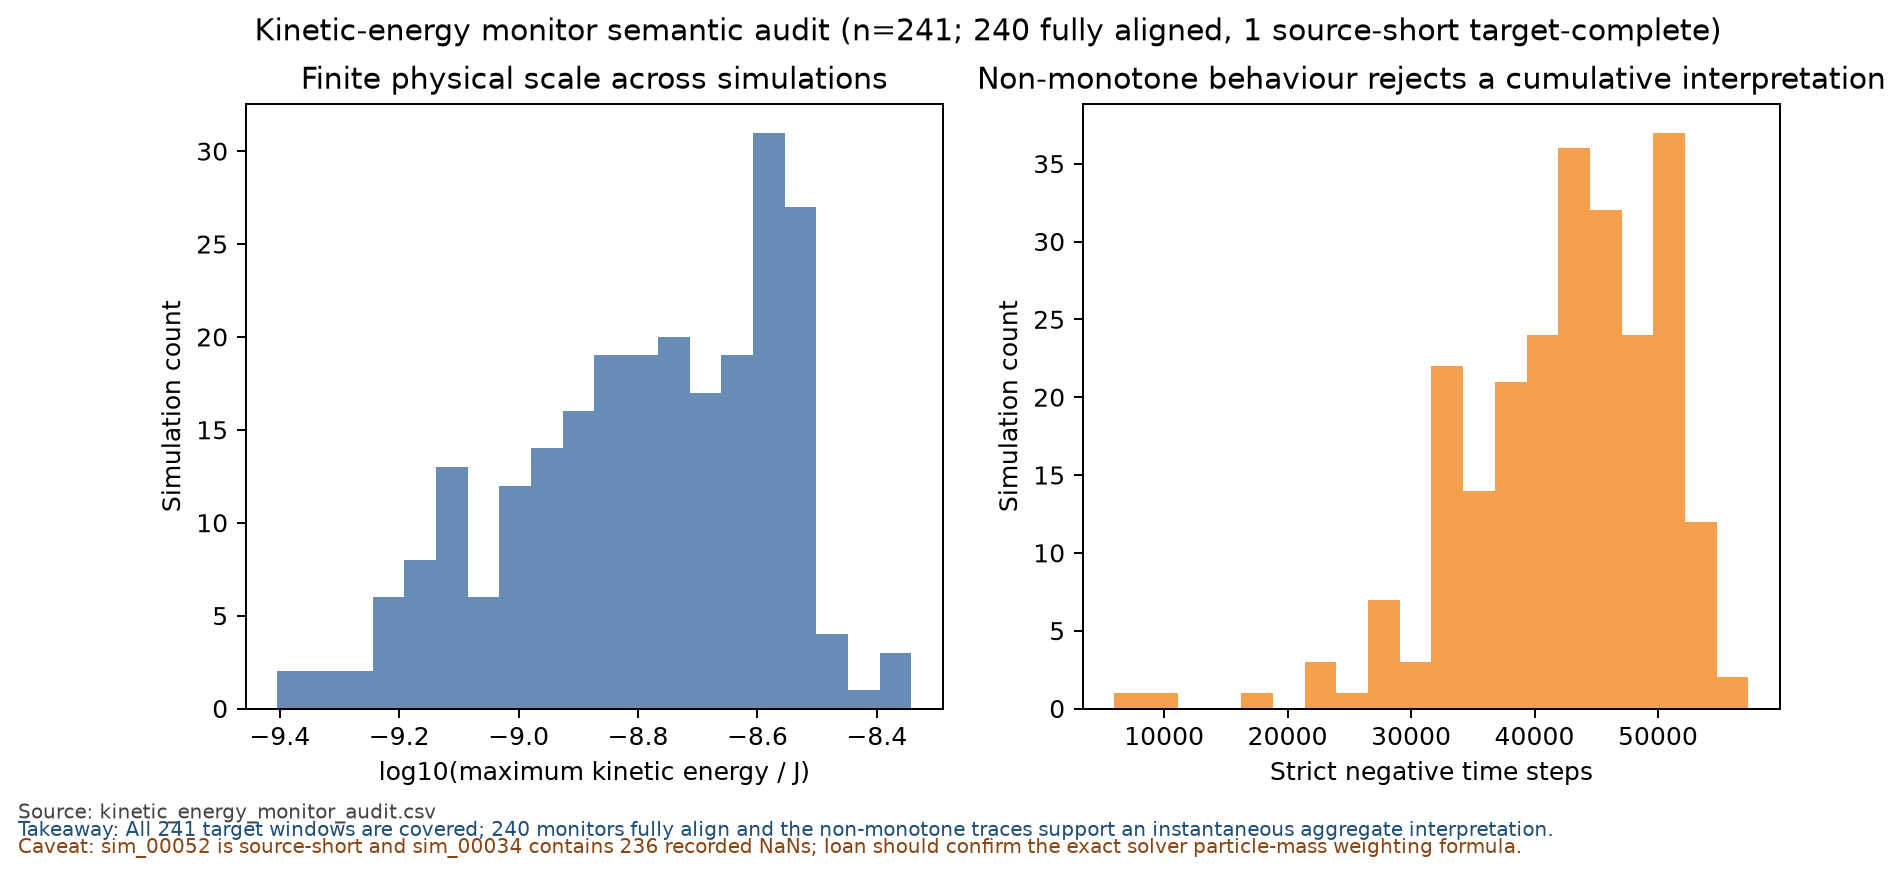

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
OUT = ROOT / "outputs" / "week6_04_new_outputs_feature_effects"
assert ROOT.name == "thesis-week6-melt-pool-audit"

config = json.loads((OUT / "phase4_configuration.json").read_text(encoding="utf-8"))
preflight = json.loads((OUT / "phase4_preflight_snapshot.json").read_text(encoding="utf-8"))
audit_ke = pd.read_csv(OUT / "kinetic_energy_monitor_audit.csv")
audit_height = pd.read_csv(OUT / "total_height_monitor_audit.csv")

display(pd.DataFrame({
    "item": ["branch", "HEAD", "dataset revision", "Phase 1 ledger SHA-256", "kinetic file", "kinetic meaning"],
    "value": [
        config["branch"],
        config["starting_head"],
        config["dataset"]["pinned_revision"],
        config["dataset"]["phase1_ledger_sha256"],
        config["kinetic_energy_monitor"]["file_name"],
        config["kinetic_energy_monitor"]["semantic_classification"],
    ],
}))
display(audit_ke[["simulation_id", "rows_align", "invalid_row_count", "strict_negative_step_count", "minimum_J", "maximum_J"]].describe(include="all"))
display(Image(filename=str(OUT / "figures" / "02_kinetic_energy_semantic_audit.png"), width=950))

The audit uses the exact pinned file, row alignment, SI-unit metadata, local aggregate-monitor documentation, and all 241 time-series traces. The target windows are fully covered in all simulations: 240 files fully align, while pinned `sim_00052` is source-short but remains target-complete. `sim_00034` contains 236 recorded `NaN` rows; one T0-endpoint `NaN` is excluded and 2,233 valid T0 rows remain. The valid traces contain many decreases, which rejects a cumulative interpretation.

What this means: a late-active median is scientifically coherent. What it cannot prove: the exact solver-side mass weighting. This is a new Phase 4 audit; the coordinate and sentinel rules are reused from Phase 1.

,simulation_id,formula,T0_observation_count,T0_reproduction_absolute_error_m,penetration_depth_not_substituted
0,sim_00001,total_height(t) = z_max(t) - z_min(t),13744,1.138636e-13,True
1,sim_00002,total_height(t) = z_max(t) - z_min(t),10906,2.167737e-12,True
2,sim_00003,total_height(t) = z_max(t) - z_min(t),10732,2.184115e-13,True
3,sim_00004,total_height(t) = z_max(t) - z_min(t),17286,9.115443e-13,True
4,sim_00005,total_height(t) = z_max(t) - z_min(t),13746,8.304640e-14,True


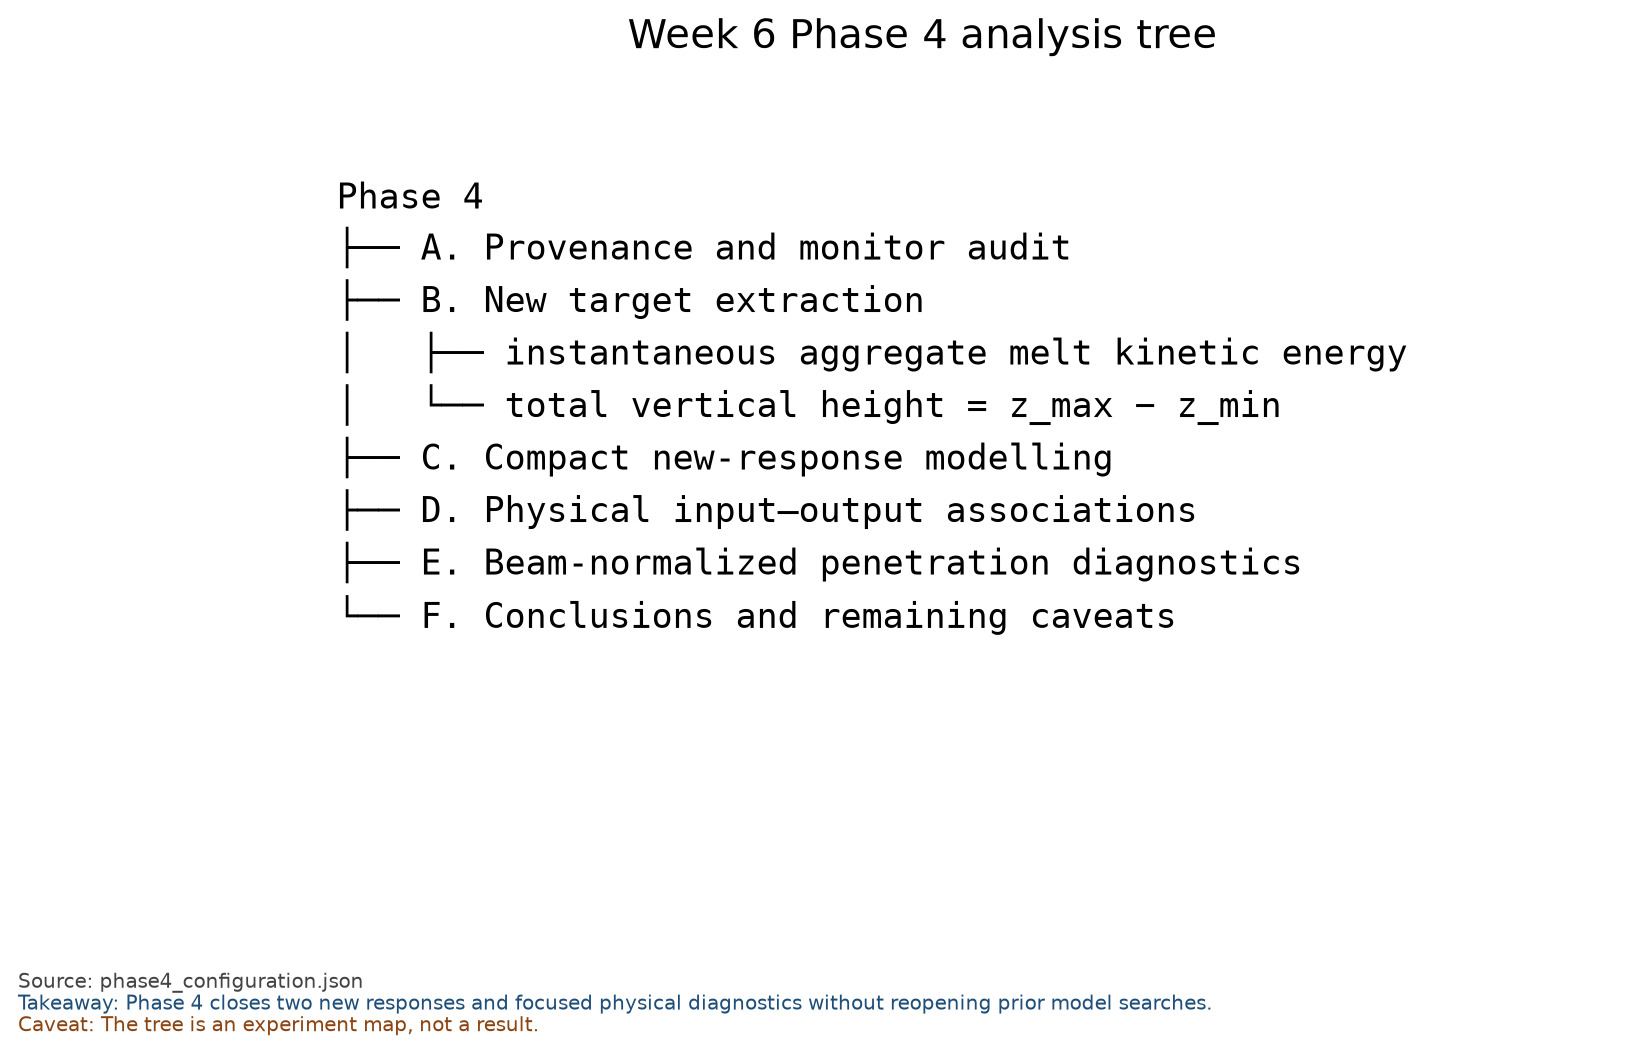

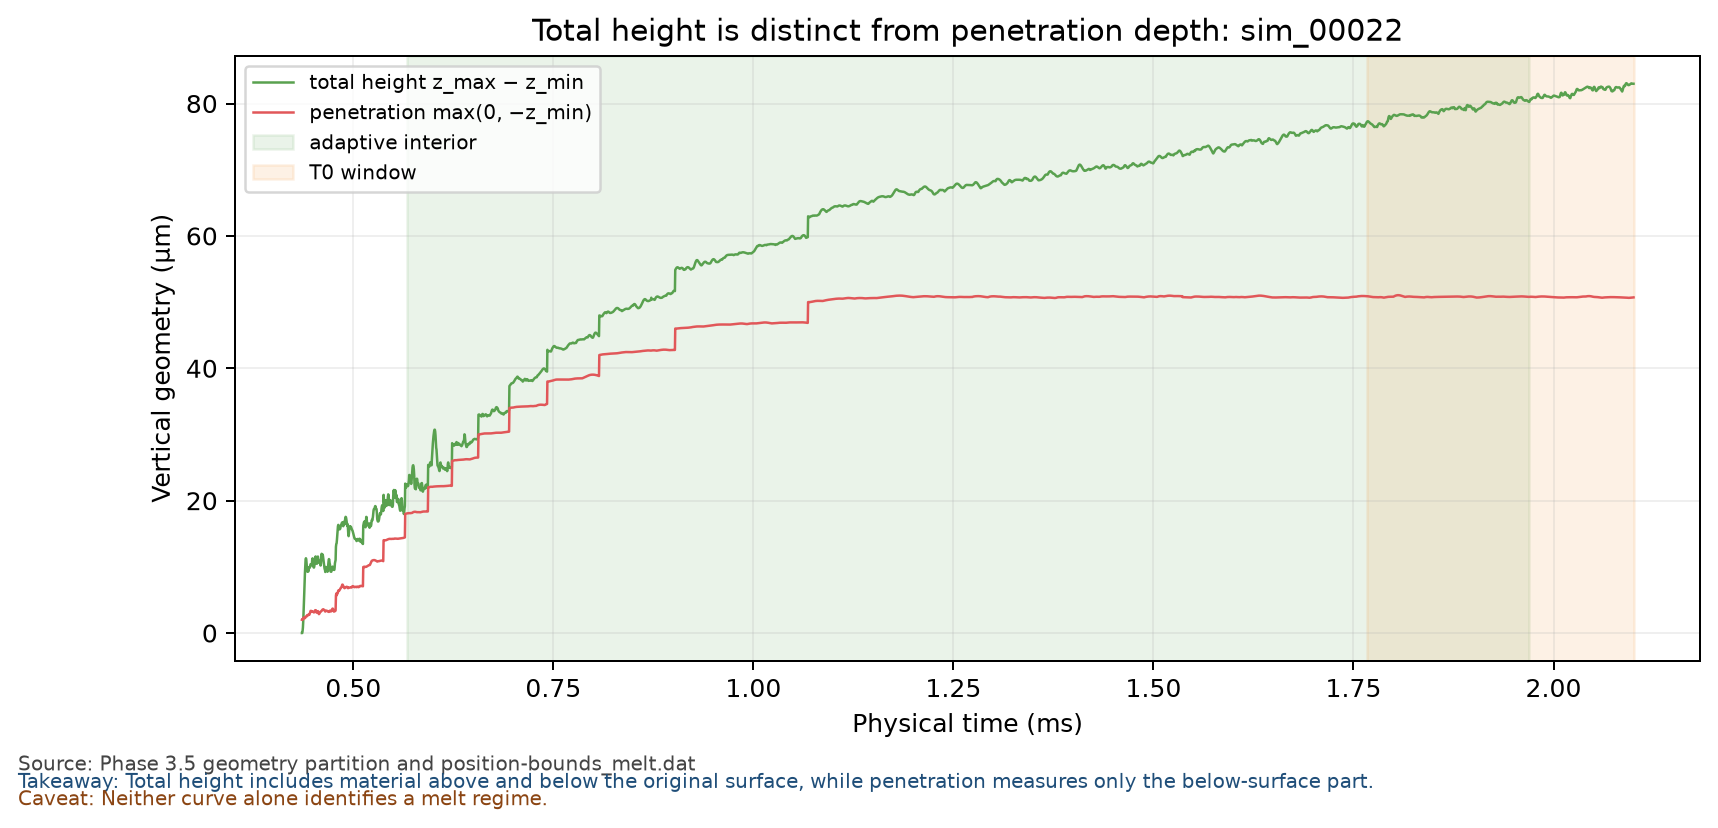

In [2]:
display(audit_height[[
    "simulation_id", "formula", "T0_observation_count",
    "T0_reproduction_absolute_error_m", "penetration_depth_not_substituted"
]].head())
display(Image(filename=str(OUT / "figures" / "01_phase4_analysis_tree.png"), width=950))
display(Image(filename=str(OUT / "figures" / "04_example_height_beside_depth.png"), width=950))

**Penetration depth** is `max(0, −z_min)`: below-surface reach. **Total vertical height** is `z_max − z_min`: the full top-to-bottom extent. For example, `z_max=20 µm` and `z_min=−50 µm` gives depth `50 µm` but total height `70 µm`.

The total-height T0 values reproduce the validated Phase 1 `delta_z` medians. This confirms identity and implementation, but neither response alone establishes a melt regime.

## B. New target extraction

The **T0 window** is the final 20% of eligible melt-present observations before the laser reaches 90% of the positive-X domain. If 100 rows are eligible, T0 uses the final 20 and takes their median.

The **adaptive active interior** is the Phase 3.5 simulation-specific interior interval. It is used once as a sensitivity comparison, not as a second target search.

,simulation_id,P,VX,LS,ST,T0_melt_pool_kinetic_energy_nJ,adaptive_melt_pool_kinetic_energy_nJ,T0_total_vertical_height_um,adaptive_total_vertical_height_um
0,sim_00001,101.127472,0.523947,45.000000,300.000000,1.011336,0.876672,74.865795,68.689696
1,sim_00002,104.101542,0.916530,88.288284,394.968413,0.861813,0.788591,92.055570,47.765399
2,sim_00003,105.276295,0.639039,76.636834,367.448583,0.759724,0.636631,62.371975,50.421600
3,sim_00004,107.176160,0.320752,87.530228,393.859644,0.996678,0.683511,72.460095,59.583221
4,sim_00005,109.759946,0.241926,45.000000,300.000000,1.031931,0.907985,84.099600,72.536612


,response,response_label,unit,primary_definition,alternative_definition,primary_available_count,alternative_available_count,paired_available_count,missing_primary_ids,missing_alternative_ids,...,primary_std,primary_q75,primary_q95,primary_max,primary_vs_alternative_spearman,median_absolute_shift,q95_absolute_shift,median_relative_shift,large_shift_simulation_ids,large_shift_values
0,kinetic_energy,T0 melt-pool kinetic energy,nJ,median over final 20% of melt-present observat...,median over the Phase 3.5 adaptive active-inte...,241,240,240,[],"[""sim_00101""]",...,0.773401,2.347466,2.907983,3.50288,0.978426,0.205904,0.585887,0.128092,"[""sim_00097"",""sim_00098"",""sim_00139"",""sim_0004...","[{""absolute_shift"":1.2013820000000002,""alterna..."
1,total_height,T0 total vertical melt-pool height,um,median over final 20% of melt-present observat...,median over the Phase 3.5 adaptive active-inte...,241,240,240,[],"[""sim_00101""]",...,18.298190,91.661430,111.093990,142.51178,0.952497,5.776571,17.078933,0.072898,"[""sim_00029"",""sim_00095"",""sim_00038"",""sim_0010...","[{""absolute_shift"":56.186483125906506,""alterna..."


,response,role,simulation_id,selection_rule,primary_value,alternative_value,absolute_target_shift,unit
0,kinetic_energy,typical_population_median,sim_00196,minimum absolute distance to the population me...,1.529661,1.177876,0.351786,nJ
1,kinetic_energy,high_response,sim_00137,largest primary response; ties use numeric ID,3.502880,3.149877,0.353003,nJ
2,kinetic_energy,largest_primary_adaptive_disagreement,sim_00097,largest absolute primary-versus-adaptive shift...,2.704938,1.503556,1.201382,nJ
3,total_height,typical_population_median,sim_00022,minimum absolute distance to the population me...,80.106185,67.607281,12.498904,um
4,total_height,high_response,sim_00038,largest primary response; ties use numeric ID,142.511780,87.151289,55.360491,um
5,total_height,largest_primary_adaptive_disagreement,sim_00029,largest absolute primary-versus-adaptive shift...,139.685420,83.498937,56.186483,um


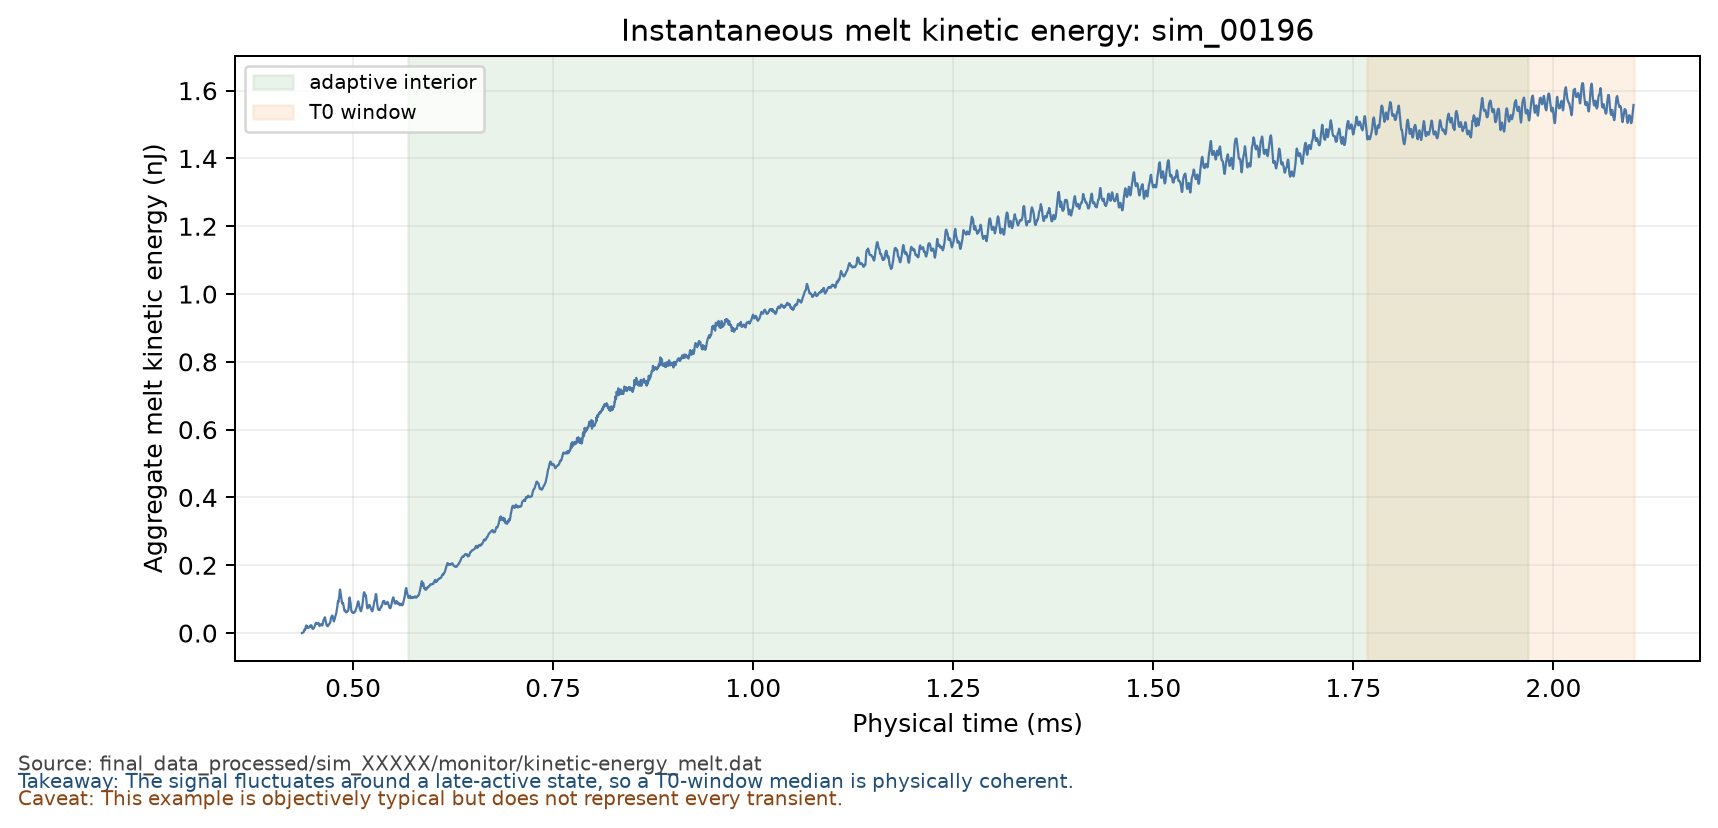

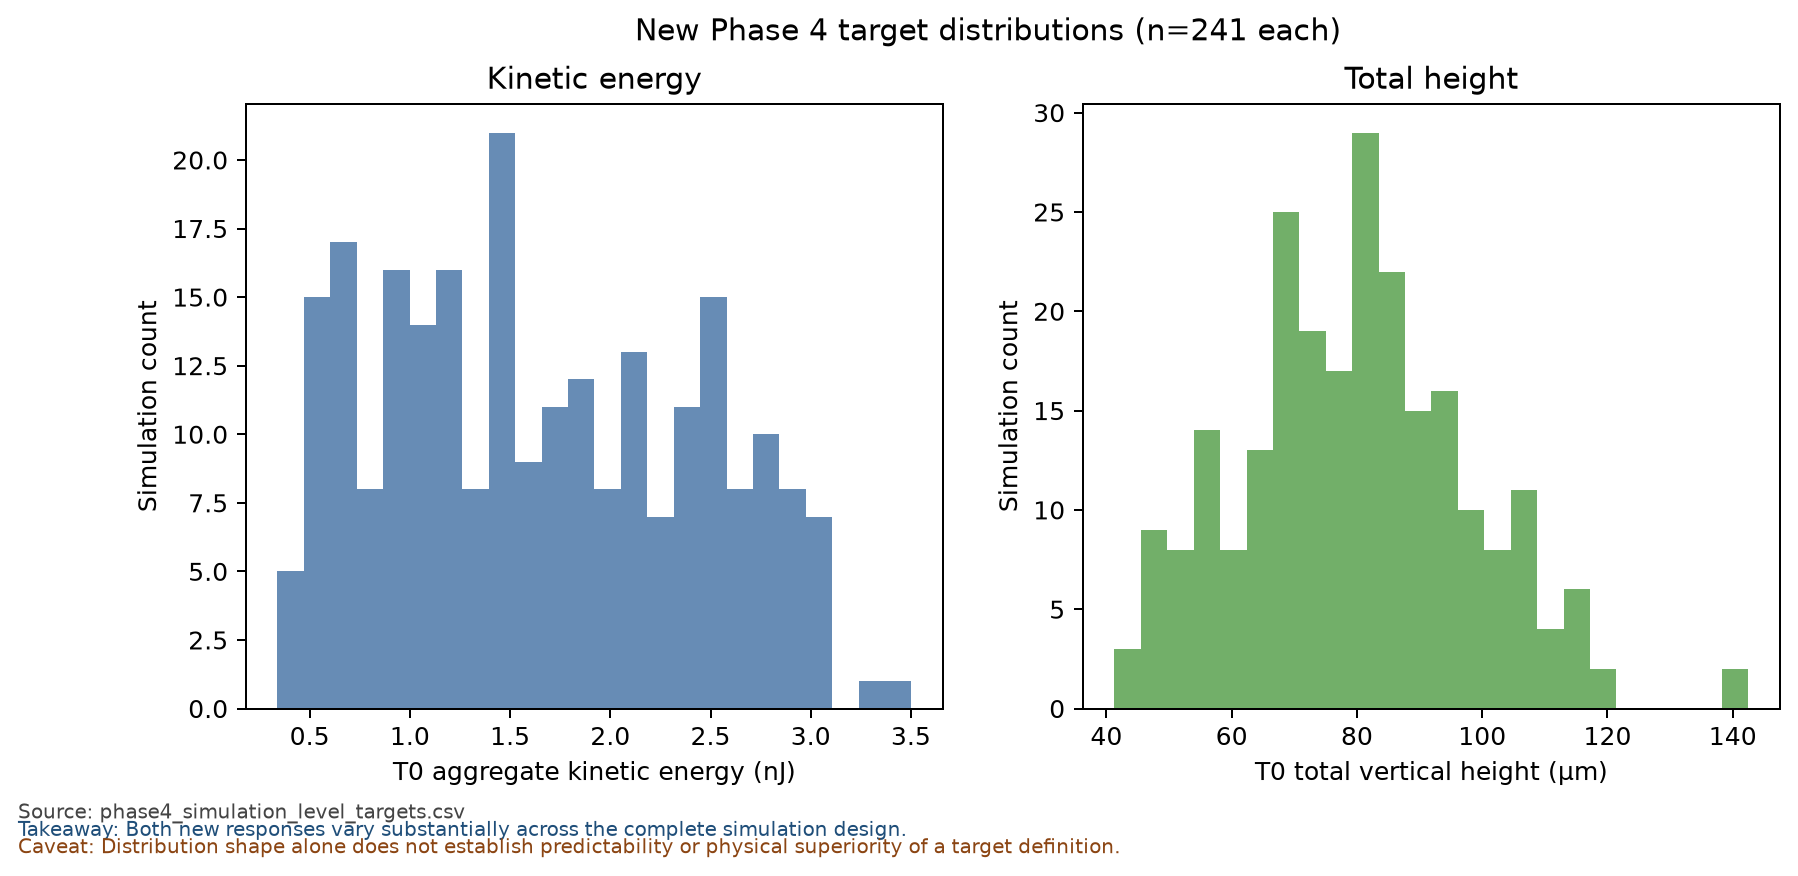

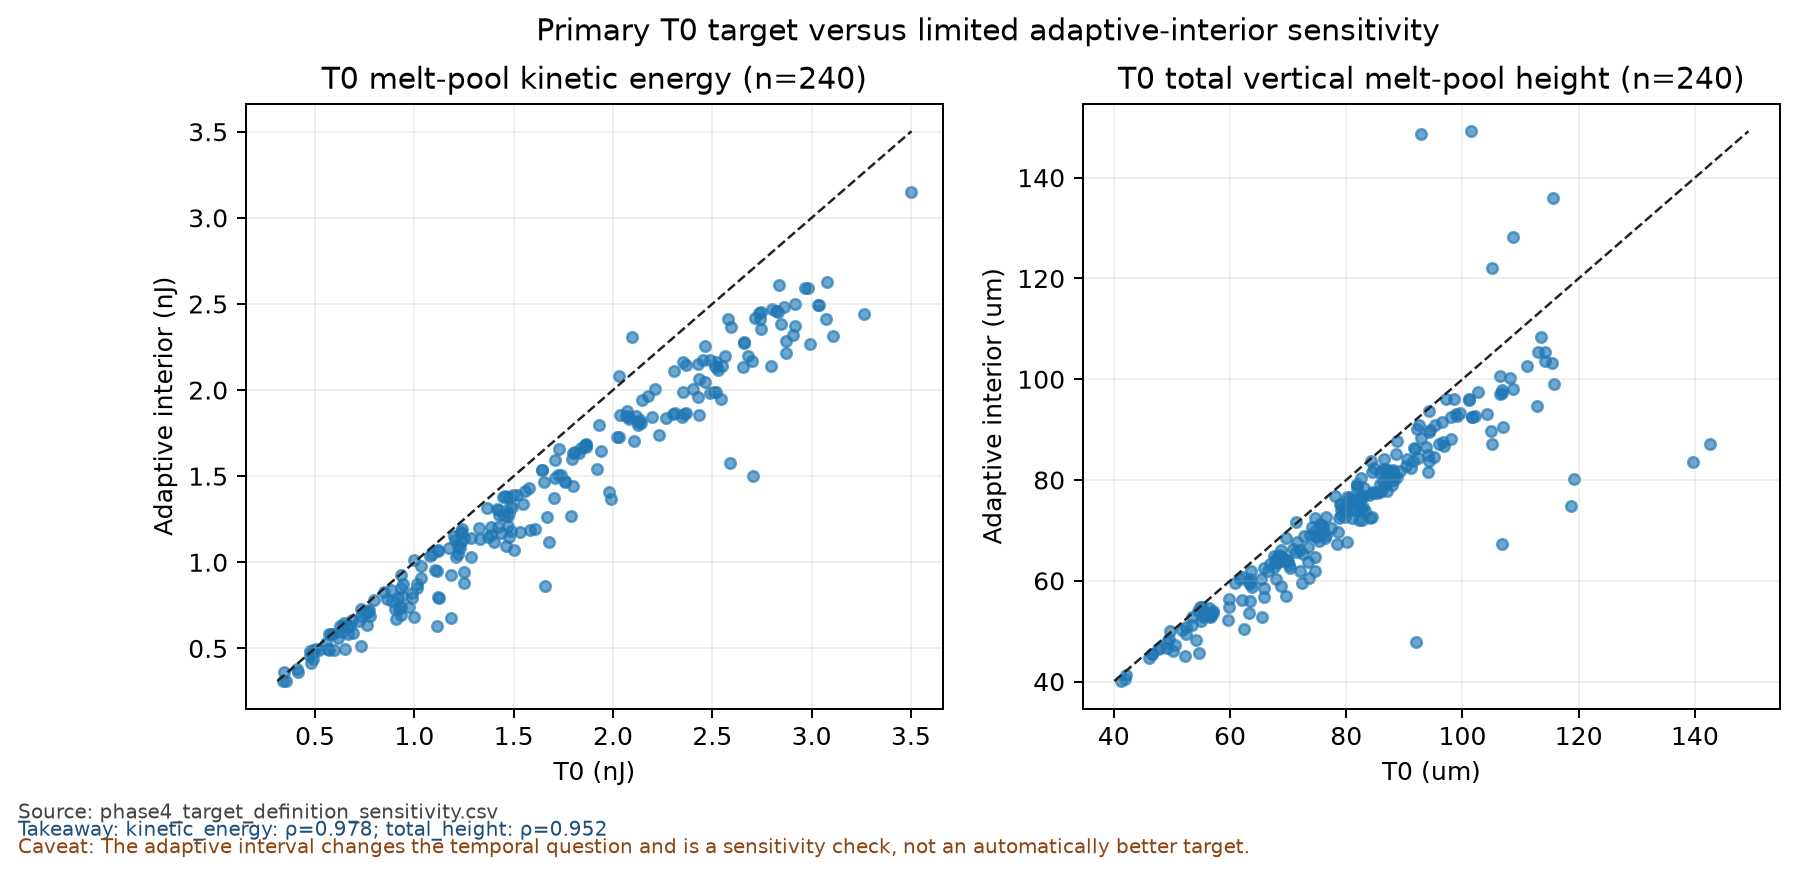

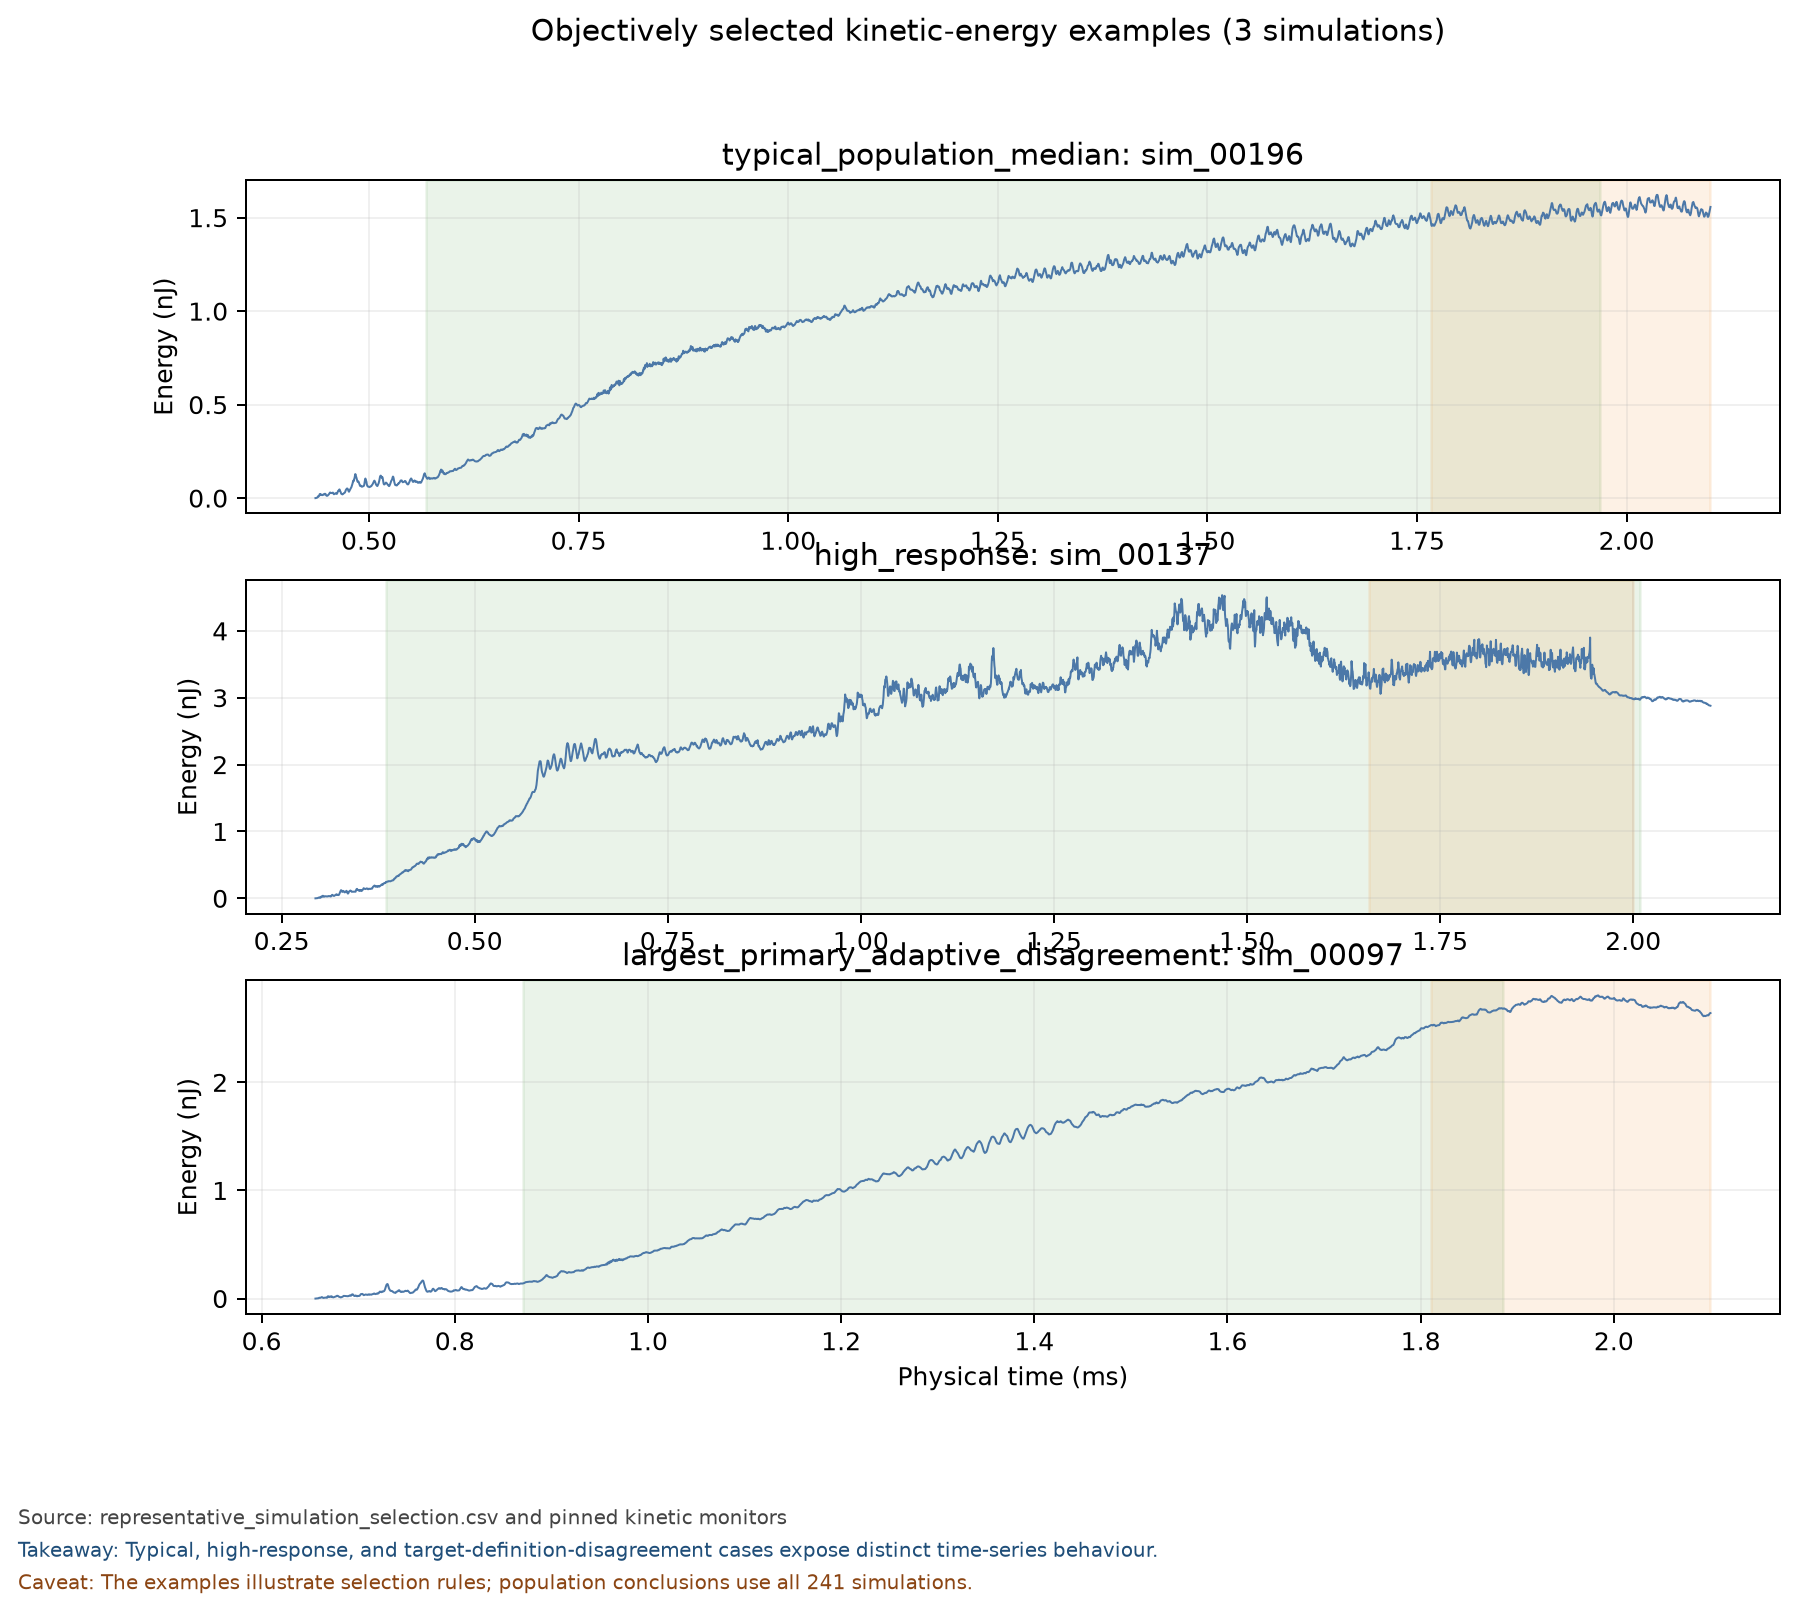

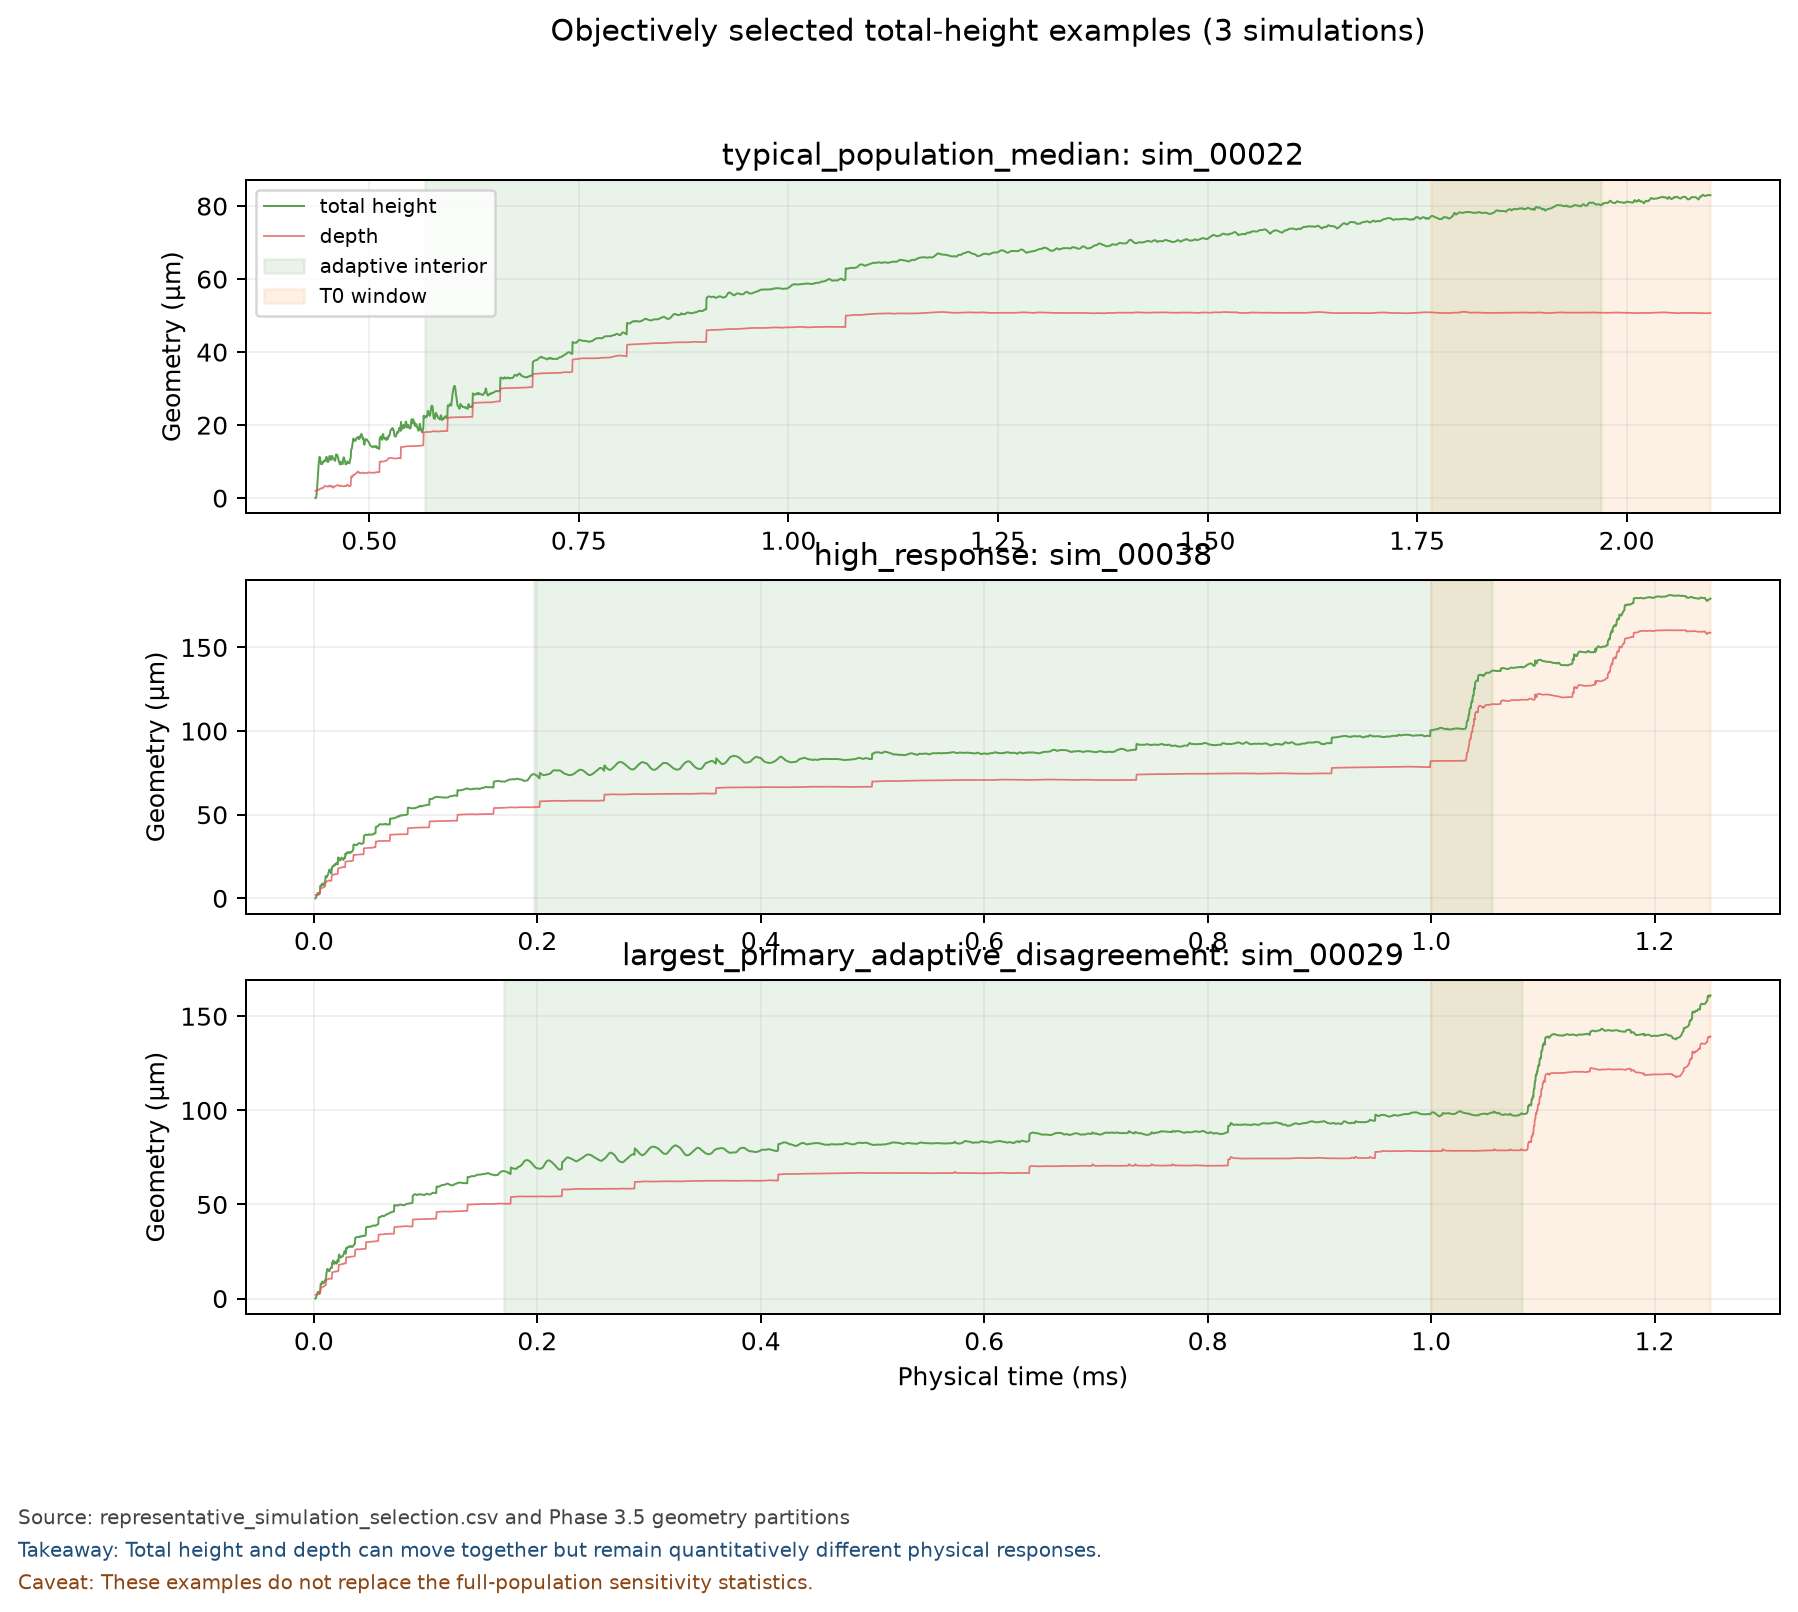

In [3]:
targets = pd.read_csv(OUT / "phase4_simulation_level_targets.csv")
sensitivity = pd.read_csv(OUT / "phase4_target_definition_sensitivity.csv")
representatives = pd.read_csv(OUT / "representative_simulation_selection.csv")

display(targets[[
    "simulation_id", "P", "VX", "LS", "ST",
    "T0_melt_pool_kinetic_energy_nJ", "adaptive_melt_pool_kinetic_energy_nJ",
    "T0_total_vertical_height_um", "adaptive_total_vertical_height_um"
]].head())
display(sensitivity)
display(representatives)
for figure_id, name in [
    (3, "example_kinetic_energy_time_series"),
    (5, "new_target_distributions"),
    (6, "primary_vs_adaptive_targets"),
    (7, "representative_kinetic_energy_examples"),
    (8, "representative_total_height_examples"),
]:
    display(Image(filename=str(OUT / "figures" / f"{figure_id:02d}_{name}.png"), width=950))

Both new primary targets are available for all 241 simulations. The primary/adaptive correlations are 0.978 for kinetic energy and 0.952 for total height.

The three examples per response are selected reproducibly: closest to the median, largest response, and largest primary/adaptive disagreement after excluding duplicates. They illustrate behaviour; all scientific summaries use the full population.

## C. Compact new-response modelling

**Leave-one-out (LOO) prediction** holds out one entire simulation, trains on the other 240, and predicts the held-out response. **Fold-local scaling** means the feature and response scalers are fitted only on those 240 training simulations.

Ridge is linear regression with **regularization**, a penalty that shrinks unstable coefficients. Polynomial Ridge adds degree-2 squares and pairwise interactions. The inner 5-fold CV chooses the regularization strength without seeing the outer held-out target.

A GP supplies a predictive mean and **predictive uncertainty**. The learned WhiteKernel **nugget** is effective unresolved model–data discrepancy; it is not identified as simulator noise. The no-nugget sensitivity keeps only fixed numerical jitter.

,response,model,mae,rmse,r2,nrmse,mean_nlpd,total_or_evaluation_95pct_coverage,warning_folds,failed_folds,bound_hit_folds,median_learned_nugget_std
0,kinetic_energy,matern32_learned_nugget,0.089010,0.173925,0.949217,0.054971,0.010263,0.970954,5,0,0,0.165898
1,kinetic_energy,matern52_learned_nugget,0.094383,0.177460,0.947132,0.056089,0.017771,0.970954,1,0,0,0.172145
2,kinetic_energy,rbf_learned_nugget,0.096325,0.178827,0.946314,0.056521,-0.007895,0.970954,0,0,0,0.173284
3,kinetic_energy,polynomial_ridge_degree2,0.096698,0.179833,0.945708,0.056839,NaN,NaN,0,0,0,NaN
4,kinetic_energy,linear_ridge,0.115385,0.187518,0.940969,0.059268,NaN,NaN,0,0,0,NaN
5,kinetic_energy,matern32_no_nugget,0.114359,0.202643,0.931062,0.064048,0.130998,0.937759,0,0,0,NaN
6,kinetic_energy,training_mean,0.664521,0.775011,-0.008351,0.244953,NaN,NaN,0,0,0,NaN
7,total_height,matern32_learned_nugget,4.205880,7.598209,0.826854,0.075053,3.490898,0.962656,0,0,0,6.458419
8,total_height,matern52_learned_nugget,4.212679,7.654735,0.824268,0.075611,3.496284,0.962656,0,0,0,6.692237
9,total_height,rbf_learned_nugget,4.247129,7.705994,0.821907,0.076118,3.500490,0.966805,0,0,0,6.890310


,response,response_label,target_unit,population_size,selected_kernel_family_model,selected_point_model,selected_uncertainty_model,selected_no_nugget_sensitivity_model,simple_models_competitive,practical_rmse_difference_threshold,kernel_replacement_rationale,learned_nugget_robust_point_advantage,learned_nugget_calibration_advantage,learned_nugget_mean_nlpd_advantage,learned_nugget_remains_useful,selected_model_mae,selected_model_rmse,selected_model_r2,selected_model_nrmse,decision_rule
0,kinetic_energy,T0 melt-pool kinetic energy,nJ,241,matern32_learned_nugget,linear_ridge,matern32_learned_nugget,matern32_no_nugget,"[""linear_ridge"",""polynomial_ridge_degree2""]",0.031639,No alternative learned-nugget kernel satisfied...,True,-0.008714,0.120736,True,0.115385,0.187518,0.940969,0.059268,replace Matérn 3/2 only for robust paired MAE ...
1,total_height,T0 total vertical melt-pool height,um,241,matern32_learned_nugget,polynomial_ridge_degree2,matern32_learned_nugget,matern32_no_nugget,"[""polynomial_ridge_degree2""]",1.012377,No alternative learned-nugget kernel satisfied...,False,-0.012448,0.575799,True,5.293909,8.522625,0.782161,0.084184,replace Matérn 3/2 only for robust paired MAE ...


,metric,difference_definition,observed_difference,ci_low,ci_high,confidence_level,bootstrap_resamples,paired_by_simulation_id,bootstrap_seed,ci_excludes_zero,robustly_favours_model_a,robustly_favours_model_b,response,target_unit,comparison_group,model_a,model_b
1,RMSE,model_a minus model_b; negative favours model_a,0.003535,0.000886,0.005688,0.95,10000,True,4011705840,True,False,True,kinetic_energy,nJ,learned_kernel_candidate_vs_matern32,matern52_learned_nugget,matern32_learned_nugget
3,RMSE,model_a minus model_b; negative favours model_a,0.004902,0.001727,0.007475,0.95,10000,True,2038088020,True,False,True,kinetic_energy,nJ,learned_kernel_candidate_vs_matern32,rbf_learned_nugget,matern32_learned_nugget
5,RMSE,model_a minus model_b; negative favours model_a,-0.013593,-0.026927,-0.005491,0.95,10000,True,1917950240,True,True,False,kinetic_energy,nJ,selected_gp_vs_baseline,matern32_learned_nugget,linear_ridge
7,RMSE,model_a minus model_b; negative favours model_a,-0.005908,-0.009084,-0.002305,0.95,10000,True,2297172438,True,True,False,kinetic_energy,nJ,selected_gp_vs_baseline,matern32_learned_nugget,polynomial_ridge_degree2
9,RMSE,model_a minus model_b; negative favours model_a,-0.601086,-0.687360,-0.508704,0.95,10000,True,4273422246,True,True,False,kinetic_energy,nJ,selected_gp_vs_baseline,matern32_learned_nugget,training_mean
11,RMSE,model_a minus model_b; negative favours model_a,-0.028719,-0.061609,-0.007974,0.95,10000,True,1254565273,True,True,False,kinetic_energy,nJ,selected_kernel_learned_nugget_vs_no_nugget,matern32_learned_nugget,matern32_no_nugget
13,RMSE,model_a minus model_b; negative favours model_a,0.056526,-0.015630,0.128425,0.95,10000,True,1681448138,False,False,False,total_height,um,learned_kernel_candidate_vs_matern32,matern52_learned_nugget,matern32_learned_nugget
15,RMSE,model_a minus model_b; negative favours model_a,0.107785,-0.031432,0.245252,0.95,10000,True,2888174756,False,False,False,total_height,um,learned_kernel_candidate_vs_matern32,rbf_learned_nugget,matern32_learned_nugget
17,RMSE,model_a minus model_b; negative favours model_a,-2.357850,-3.412964,-1.301475,0.95,10000,True,2938380882,True,True,False,total_height,um,selected_gp_vs_baseline,matern32_learned_nugget,linear_ridge
19,RMSE,model_a minus model_b; negative favours model_a,-0.924417,-1.667208,-0.165065,0.95,10000,True,1417783903,True,True,False,total_height,um,selected_gp_vs_baseline,matern32_learned_nugget,polynomial_ridge_degree2


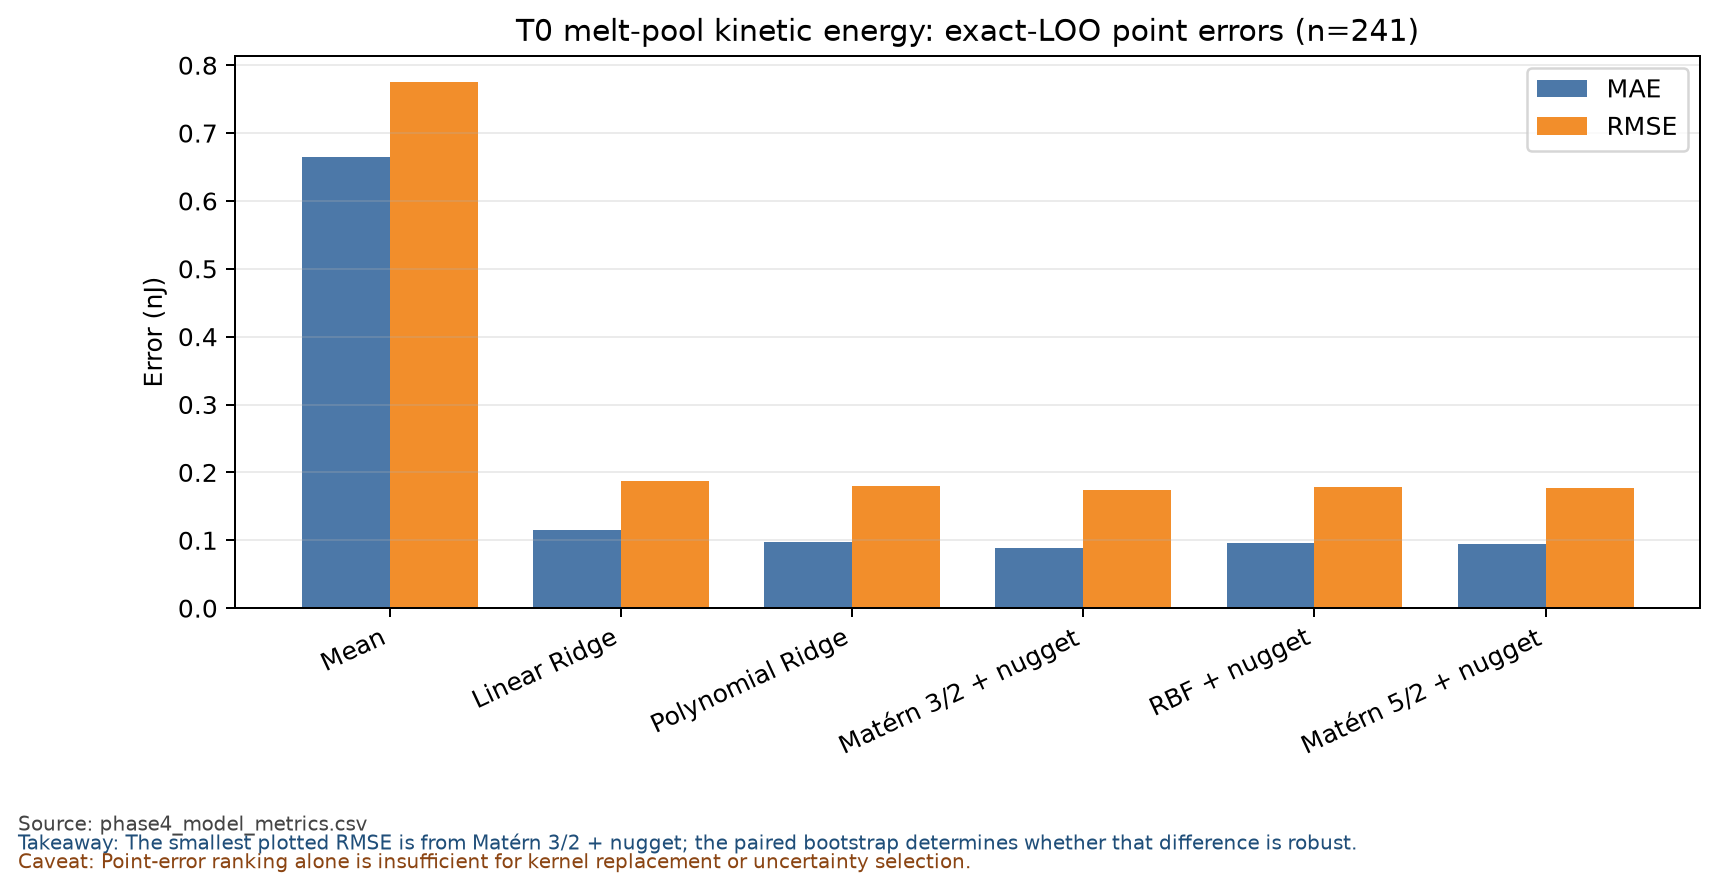

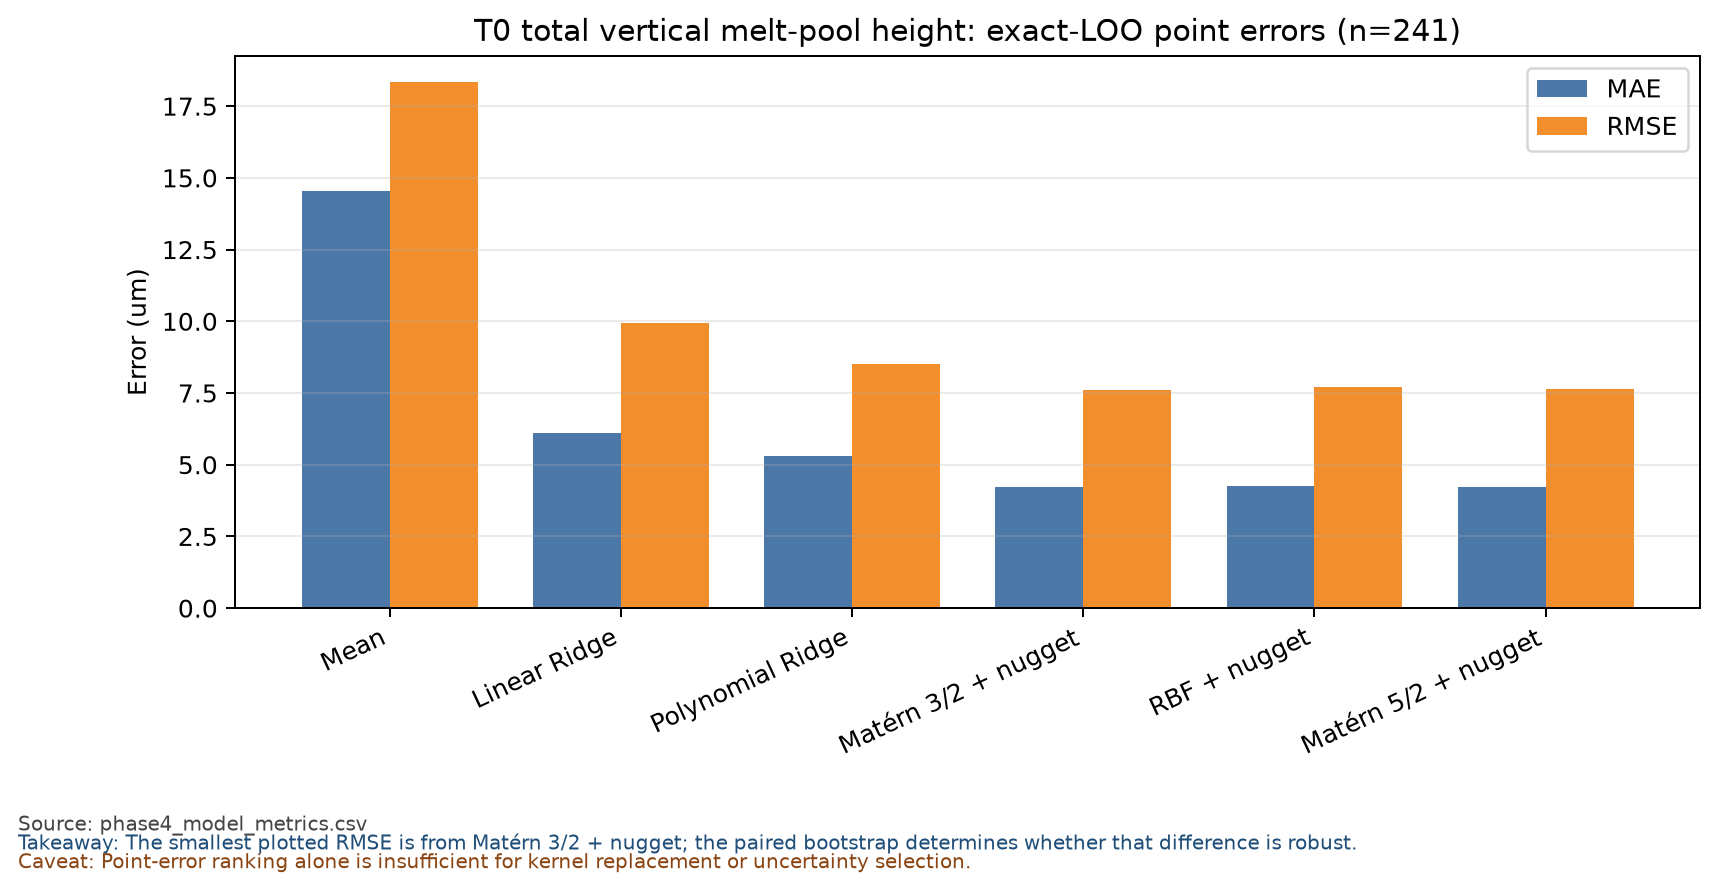

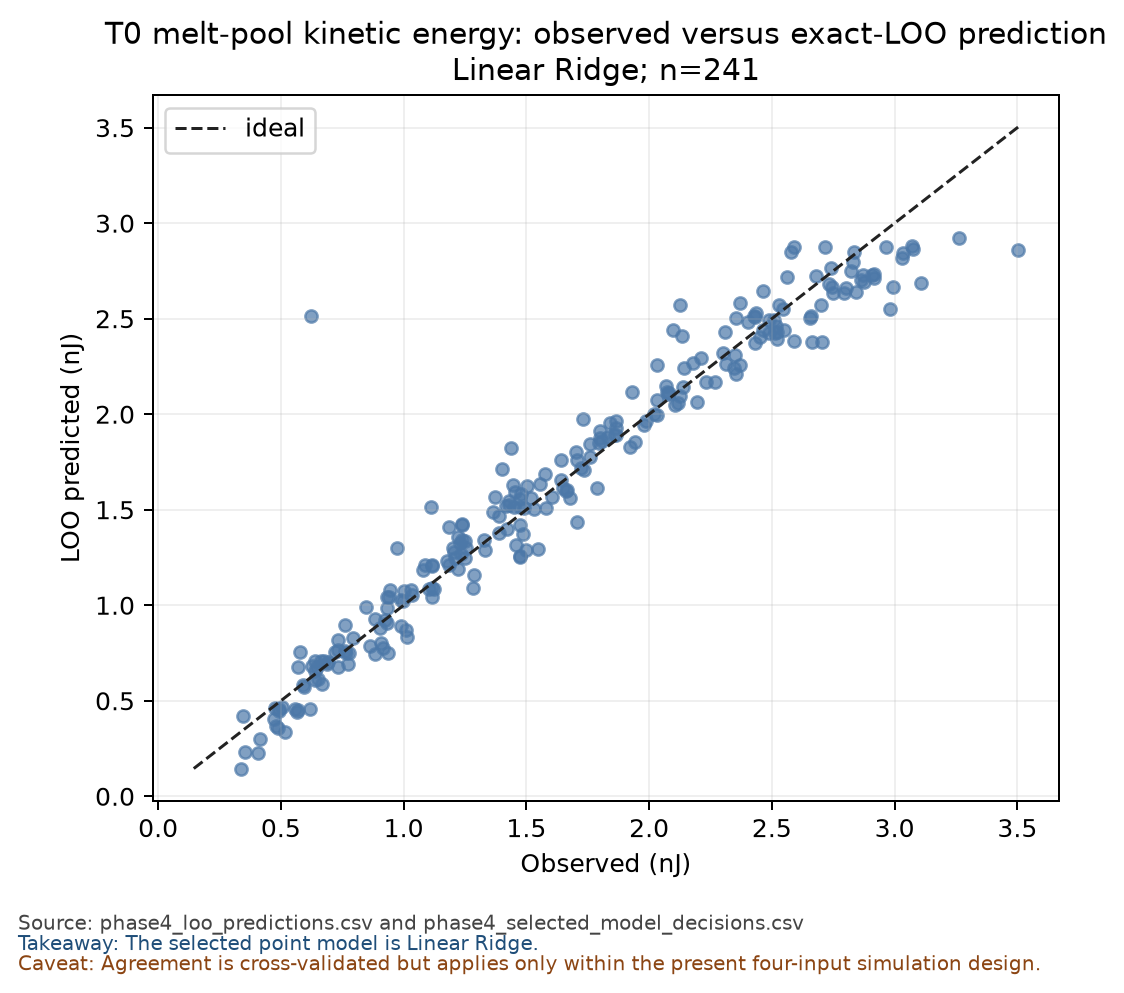

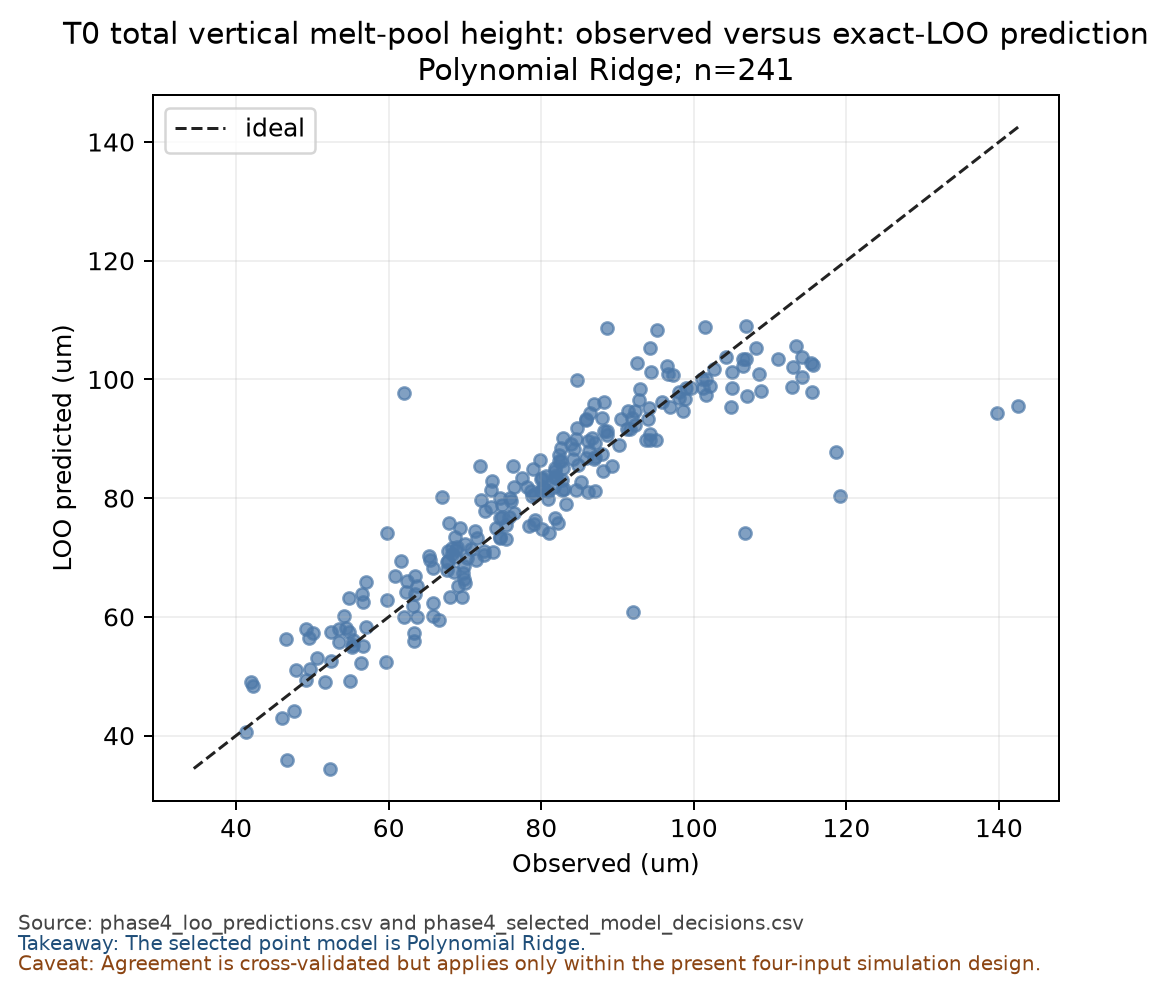

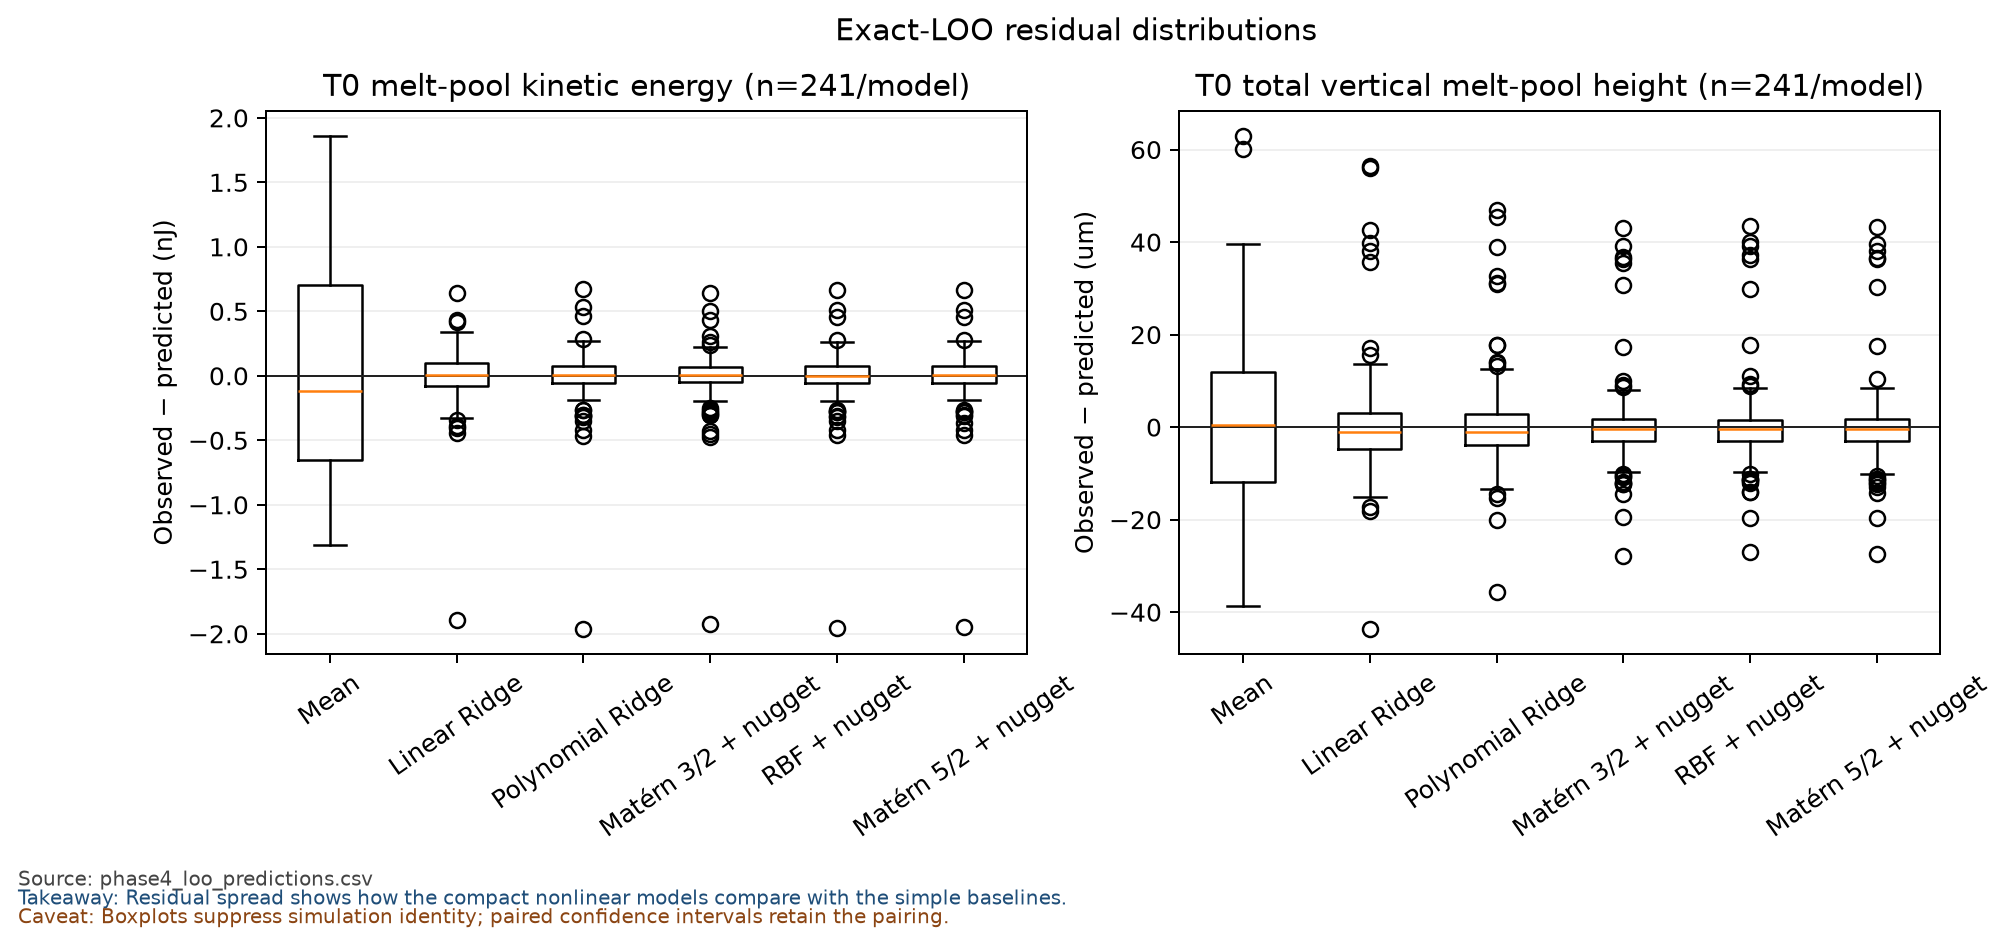

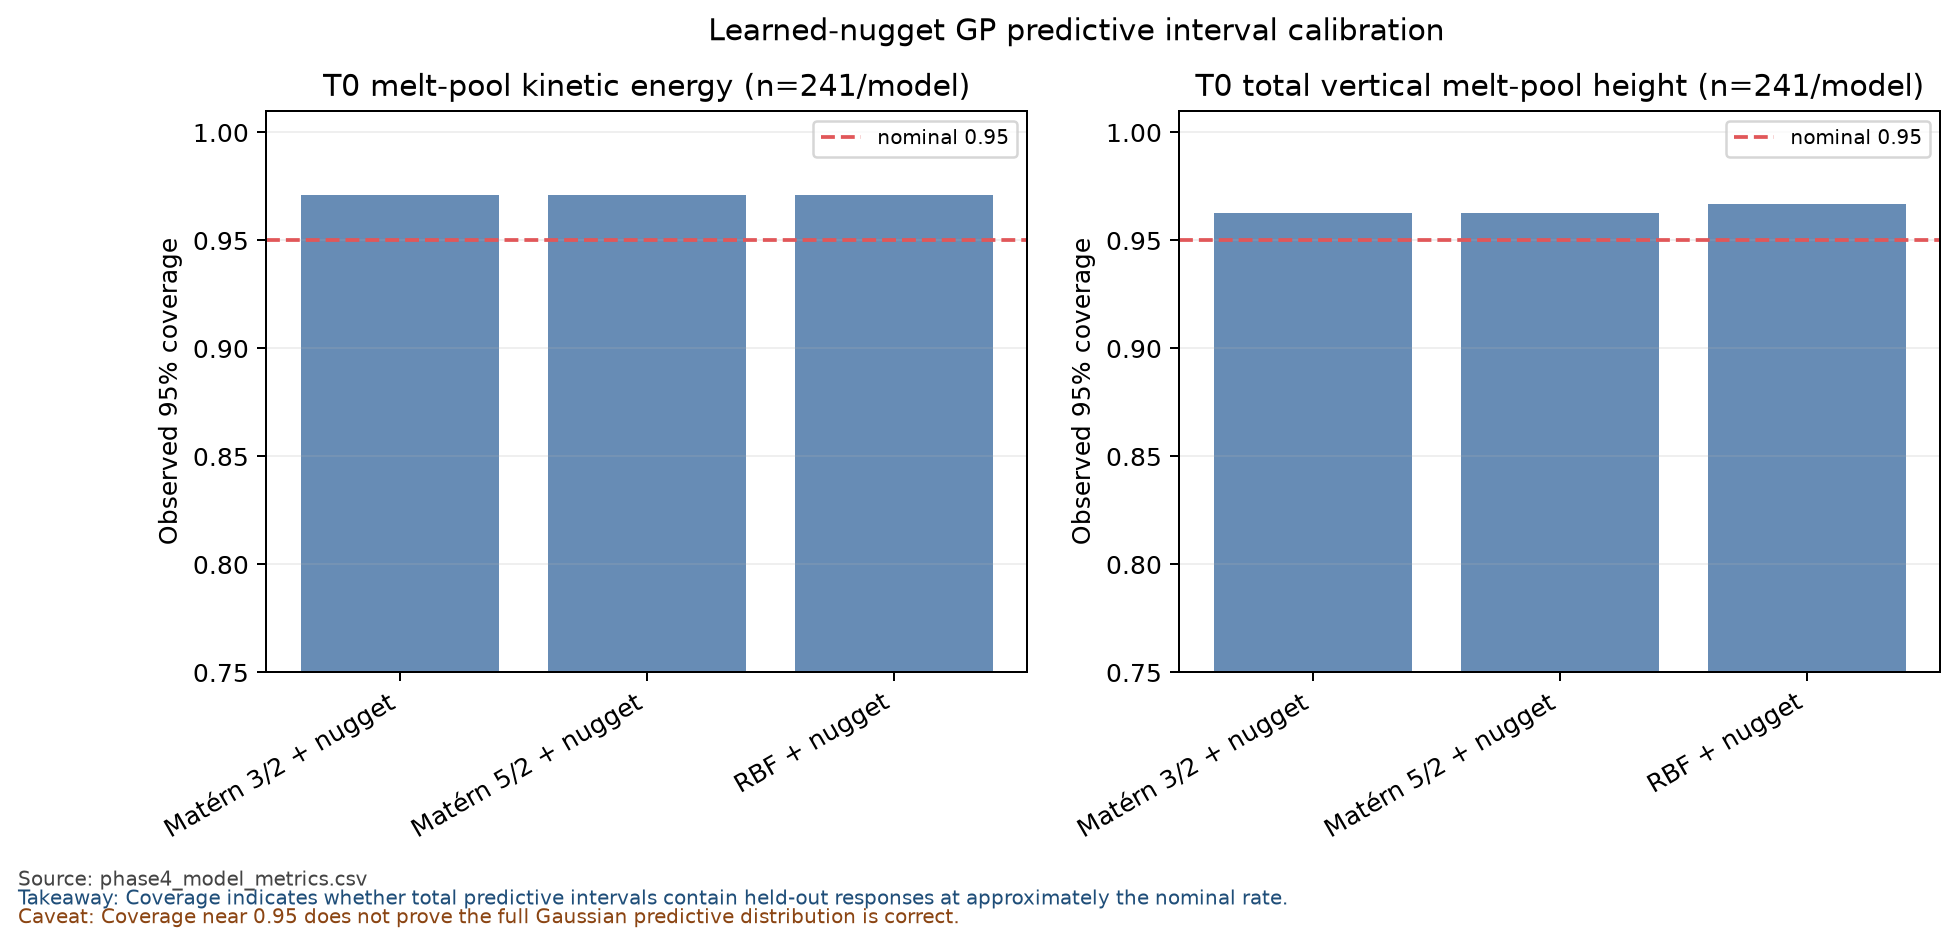

In [4]:
model_metrics = pd.read_csv(OUT / "phase4_model_metrics.csv")
comparisons = pd.read_csv(OUT / "phase4_paired_bootstrap_comparisons.csv")
decisions = pd.read_csv(OUT / "phase4_selected_model_decisions.csv")

display(model_metrics[[
    "response", "model", "mae", "rmse", "r2", "nrmse",
    "mean_nlpd", "total_or_evaluation_95pct_coverage",
    "warning_folds", "failed_folds", "bound_hit_folds",
    "median_learned_nugget_std"
]])
display(decisions)
display(comparisons[comparisons["metric"].eq("RMSE")])
for figure_id, name in [
    (9, "kinetic_energy_model_comparison"),
    (10, "total_height_model_comparison"),
    (11, "kinetic_energy_observed_vs_loo"),
    (12, "total_height_observed_vs_loo"),
    (13, "loo_residual_distributions"),
    (14, "predictive_interval_diagnostics"),
]:
    display(Image(filename=str(OUT / "figures" / f"{figure_id:02d}_{name}.png"), width=950))

Kinetic energy selects `linear_ridge` for point prediction and `matern32_learned_nugget` for uncertainty. Total height selects `polynomial_ridge_degree2` and `matern32_learned_nugget` respectively.

A paired bootstrap resamples simulation identities together. Its **confidence interval** quantifies uncertainty in the paired MAE/RMSE difference. The GP improvements over the selected simple point models are statistically detectable, but smaller than the predeclared practical thresholds (0.03164 nJ and 1.012 µm), defined as the larger of 1% of target range and 2% of target IQR. This is why parsimony wins for point prediction while the learned-nugget GP remains the uncertainty model.

A kernel changes only when both errors improve robustly without calibration or optimizer deterioration. These results apply to the two new targets only.

## D. Physical input–output relationships

**Spearman correlation** measures monotone rank association; +1 means identical ranking, −1 the reverse. A **standardized coefficient** reports the Ridge association after both input and output use standard-deviation units, conditional on the other inputs.

A **controlled-effect curve** varies one input while holding the other three at declared references. An **interaction** means the fitted association of one input changes with another. Curves and P×VX/P×LS surfaces are masked in sparse regions.

**Association versus causation:** these simulation-design patterns say “associated with” or “the fitted model predicts conditional on references.” They do not prove a physical mechanism.

,response,response_label,response_unit,feature,feature_unit,spearman_rho,sample_size,analysis_type,causal_claim,ci_low,ci_high,confidence_level,bootstrap_resamples,bootstrap_seed,resample_unit
0,width,T0 melt-pool width,um,P,W,0.503091,241,raw descriptive association,False,0.398467,0.594875,0.95,10000,1583092981,simulation
1,width,T0 melt-pool width,um,VX,m/s,-0.688674,241,raw descriptive association,False,-0.745507,-0.619040,0.95,10000,1177097433,simulation
2,width,T0 melt-pool width,um,LS,um,0.469168,241,raw descriptive association,False,0.359154,0.570810,0.95,10000,526399685,simulation
3,width,T0 melt-pool width,um,ST,K,0.199785,241,raw descriptive association,False,0.066837,0.327647,0.95,10000,2478345637,simulation
4,depth,T0 penetration depth,um,P,W,0.788842,241,raw descriptive association,False,0.729098,0.832698,0.95,10000,2338504229,simulation
5,depth,T0 penetration depth,um,VX,m/s,-0.437835,241,raw descriptive association,False,-0.525912,-0.339033,0.95,10000,3127917997,simulation
6,depth,T0 penetration depth,um,LS,um,-0.019216,241,raw descriptive association,False,-0.154086,0.115824,0.95,10000,4049433169,simulation
7,depth,T0 penetration depth,um,ST,K,0.051461,241,raw descriptive association,False,-0.078057,0.180846,0.95,10000,2056269603,simulation
8,kinetic_energy,T0 melt-pool kinetic energy,nJ,P,W,0.968095,241,raw descriptive association,False,0.939876,0.982112,0.95,10000,4209568878,simulation
9,kinetic_energy,T0 melt-pool kinetic energy,nJ,VX,m/s,-0.015503,241,raw descriptive association,False,-0.133772,0.106333,0.95,10000,2971377563,simulation


,response,response_label,response_unit,feature,feature_unit,standardized_coefficient,selected_alpha,five_fold_cv_standardized_rmse,sample_size,x_standardized,y_standardized,interpretation
0,width,T0 melt-pool width,um,P,W,0.474987,0.000001,0.248048,241,True,True,conditional linear association after holding t...
1,width,T0 melt-pool width,um,VX,m/s,-0.748135,0.000001,0.248048,241,True,True,conditional linear association after holding t...
2,width,T0 melt-pool width,um,LS,um,0.373058,0.000001,0.248048,241,True,True,conditional linear association after holding t...
3,width,T0 melt-pool width,um,ST,K,0.026220,0.000001,0.248048,241,True,True,conditional linear association after holding t...
4,depth,T0 penetration depth,um,P,W,0.818718,1.000000,0.380264,241,True,True,conditional linear association after holding t...
5,depth,T0 penetration depth,um,VX,m/s,-0.499780,1.000000,0.380264,241,True,True,conditional linear association after holding t...
6,depth,T0 penetration depth,um,LS,um,-0.214166,1.000000,0.380264,241,True,True,conditional linear association after holding t...
7,depth,T0 penetration depth,um,ST,K,-0.048756,1.000000,0.380264,241,True,True,conditional linear association after holding t...
8,kinetic_energy,T0 melt-pool kinetic energy,nJ,P,W,0.972567,0.000001,0.229783,241,True,True,conditional linear association after holding t...
9,kinetic_energy,T0 melt-pool kinetic energy,nJ,VX,m/s,-0.094100,0.000001,0.229783,241,True,True,conditional linear association after holding t...


,response,plot_type,varying_features,profile,supported_fraction,model_configuration,training_sample_size
0,width,controlled_curve,P,median_reference,1.000000,matern32_learned_nugget,241
1,width,controlled_curve,VX,median_reference,1.000000,matern32_learned_nugget,241
2,width,controlled_curve,LS,median_reference,1.000000,matern32_learned_nugget,241
3,width,controlled_curve,ST,median_reference,1.000000,matern32_learned_nugget,241
4,width,interaction_surface,P x VX,other features at medians,0.850156,matern32_learned_nugget,241
5,width,interaction_surface,P x LS,other features at medians,0.832466,matern32_learned_nugget,241
6,depth,controlled_curve,P,median_reference,1.000000,matern32_learned_nugget,230
7,depth,controlled_curve,VX,median_reference,1.000000,matern32_learned_nugget,230
8,depth,controlled_curve,LS,median_reference,1.000000,matern32_learned_nugget,230
9,depth,controlled_curve,ST,median_reference,1.000000,matern32_learned_nugget,230


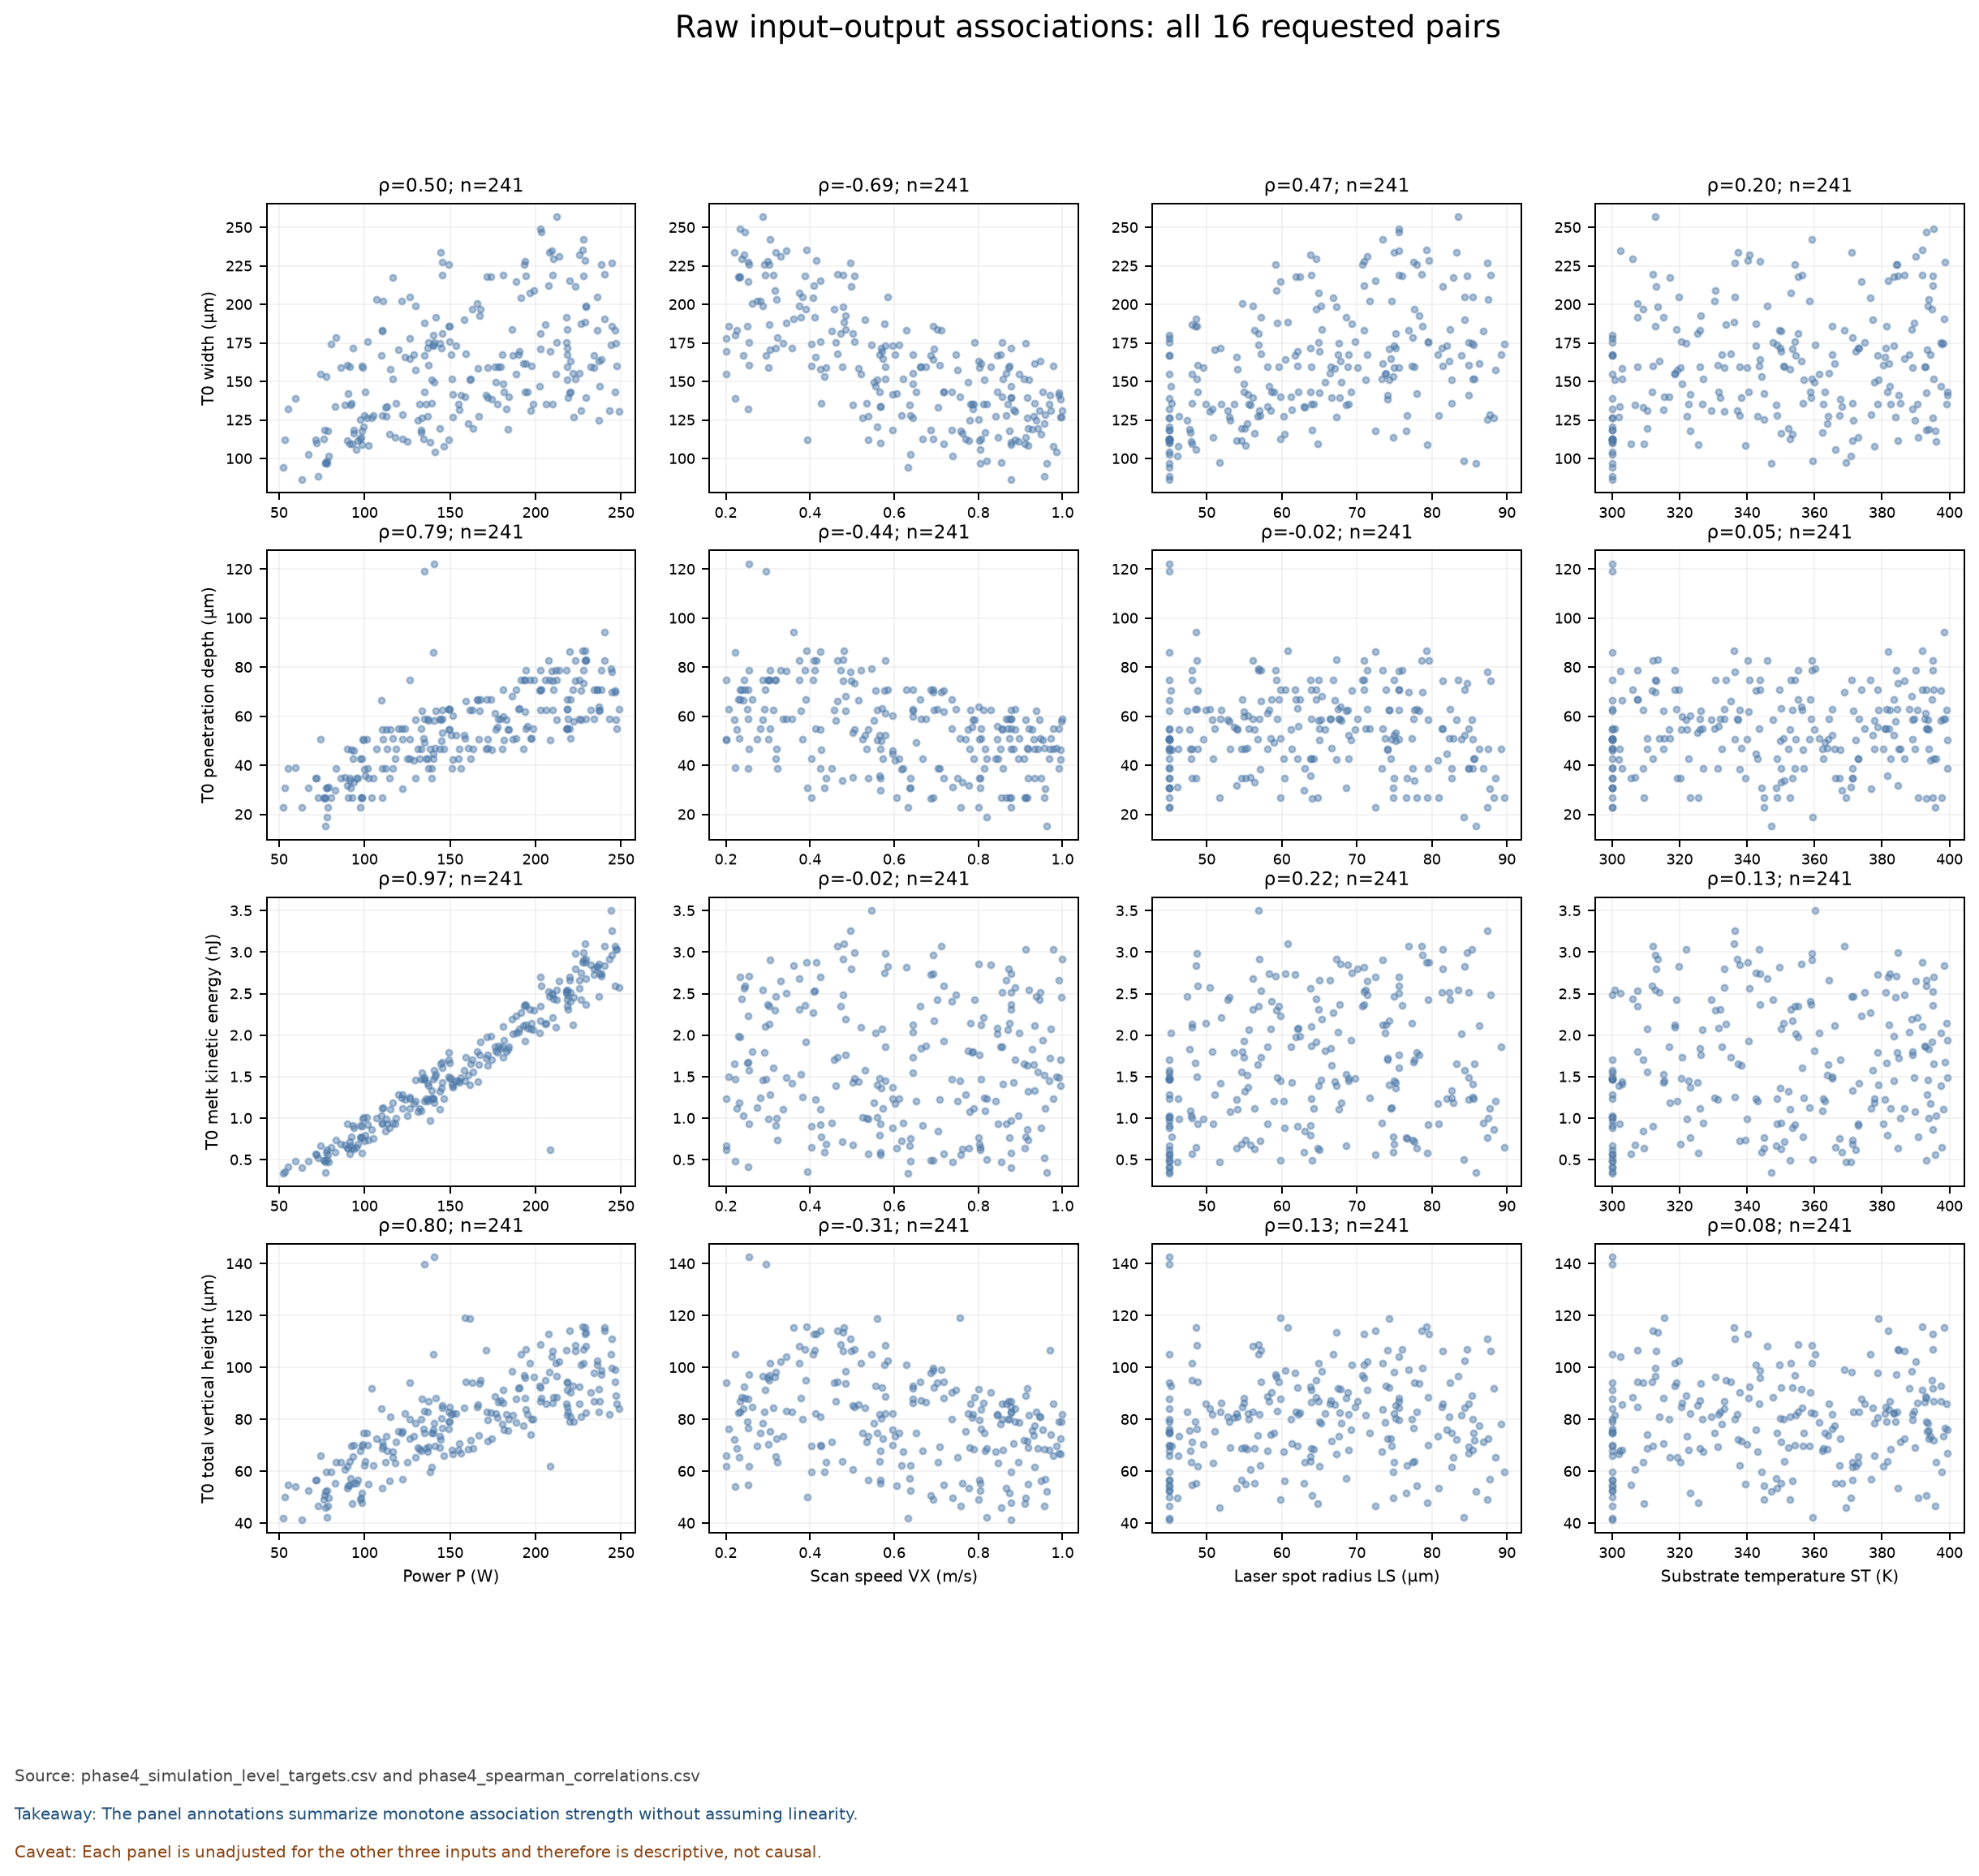

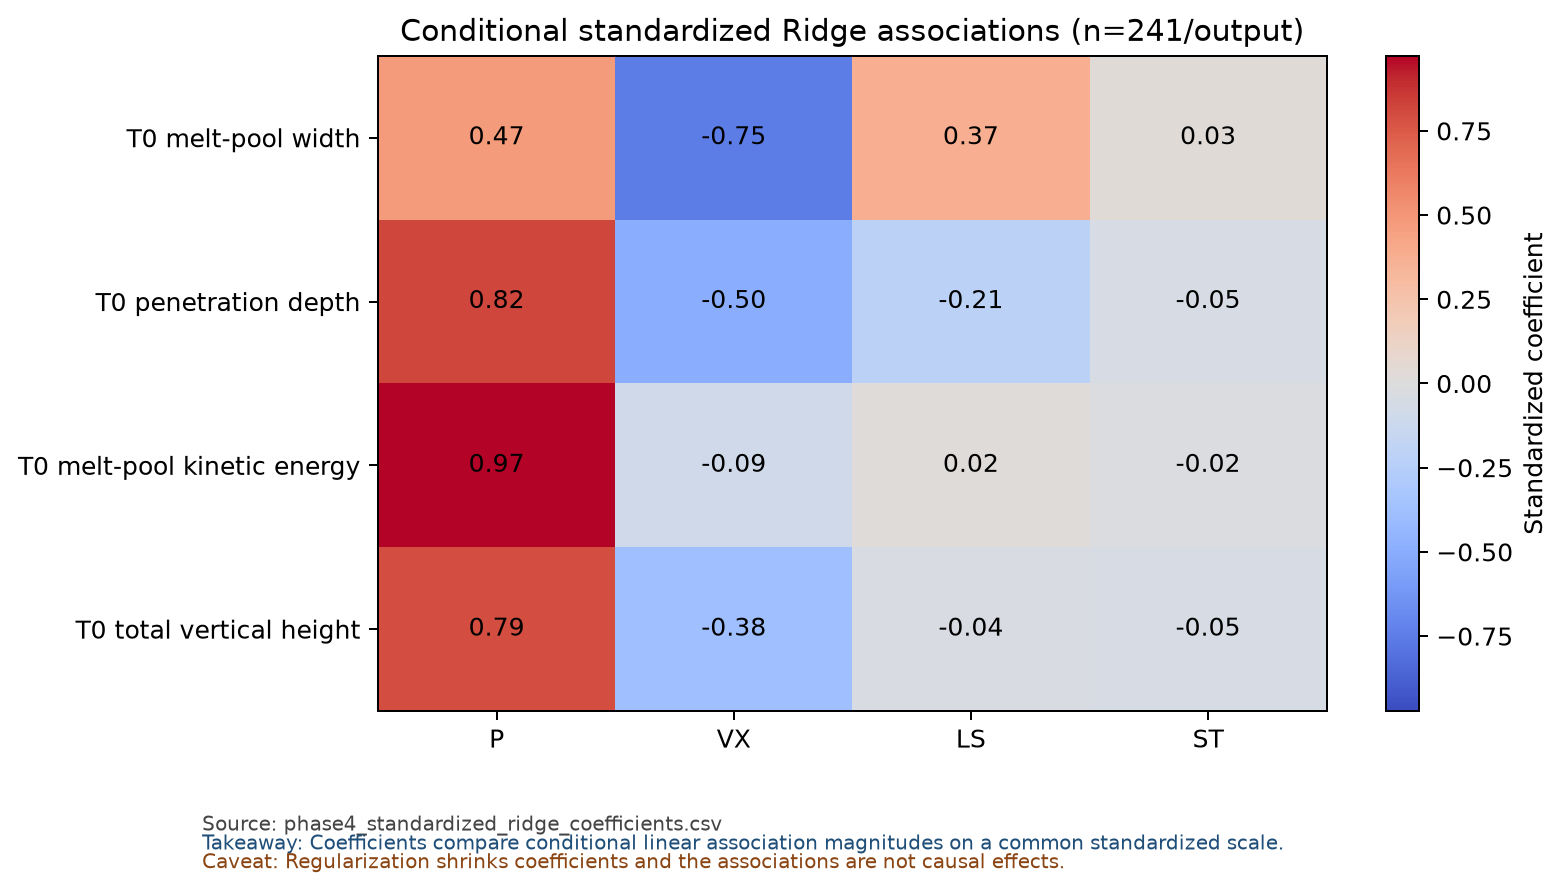

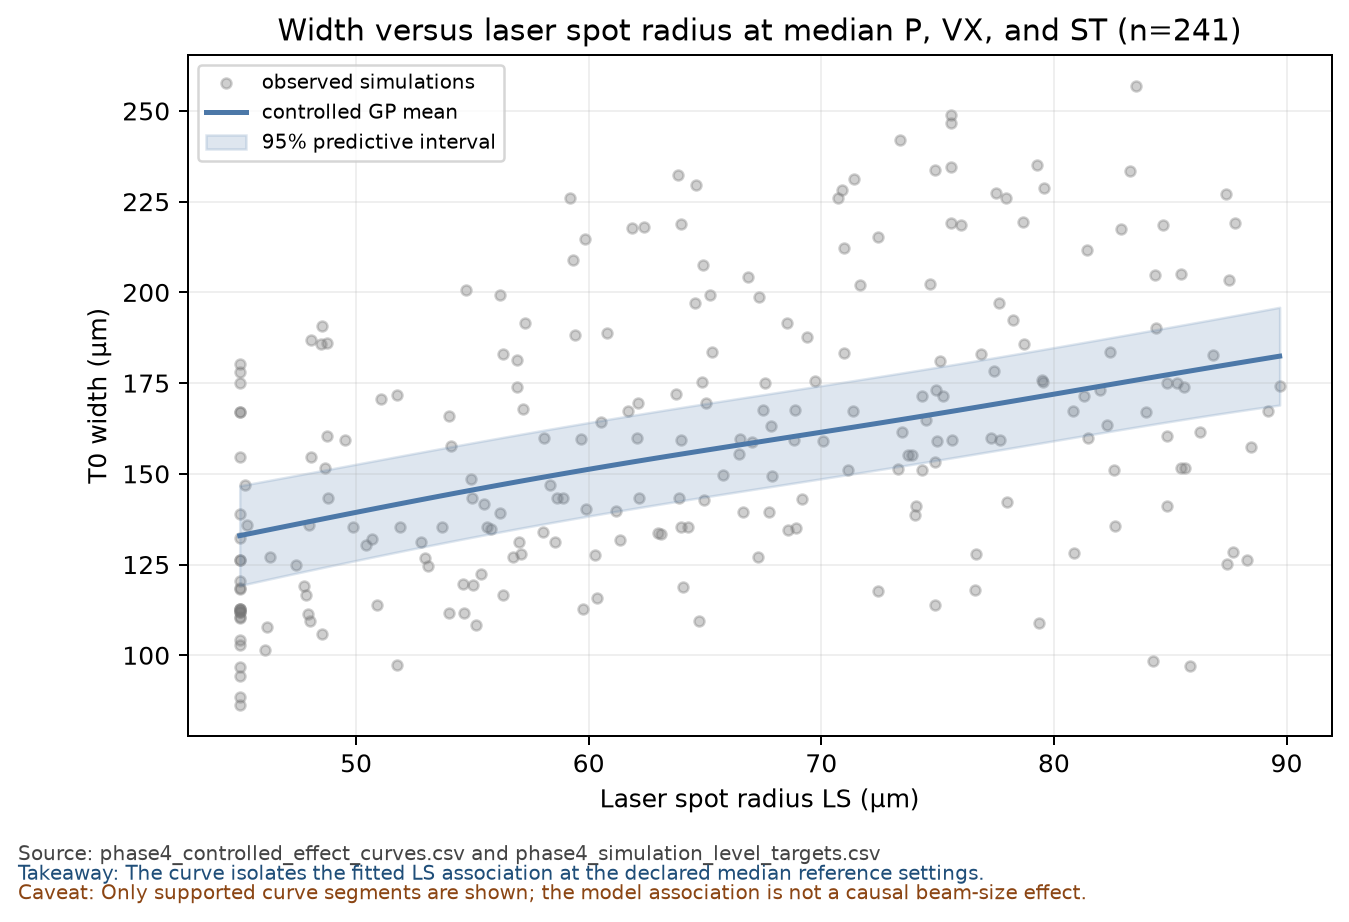

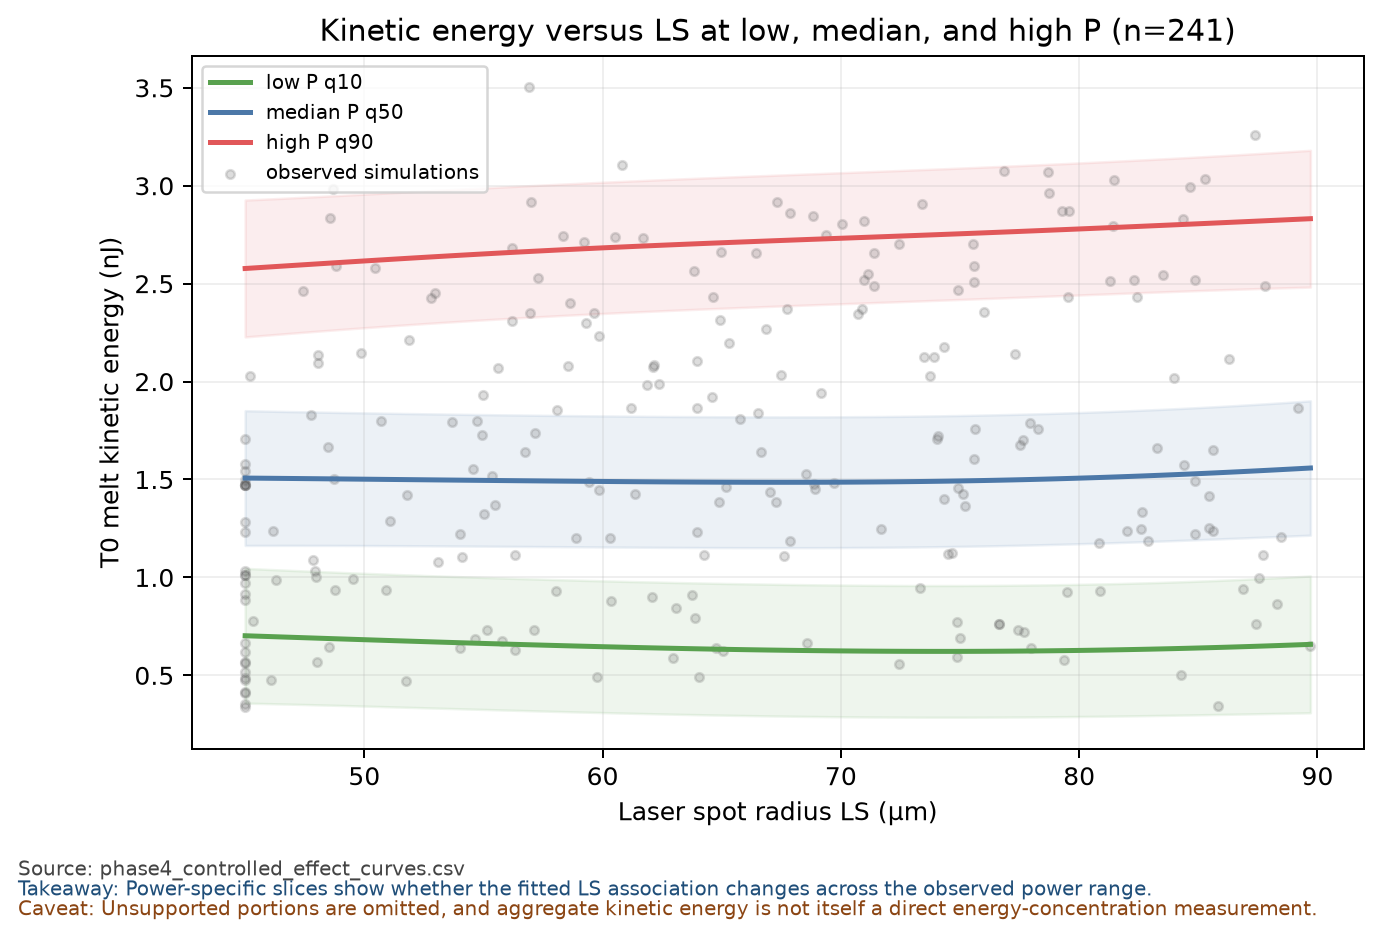

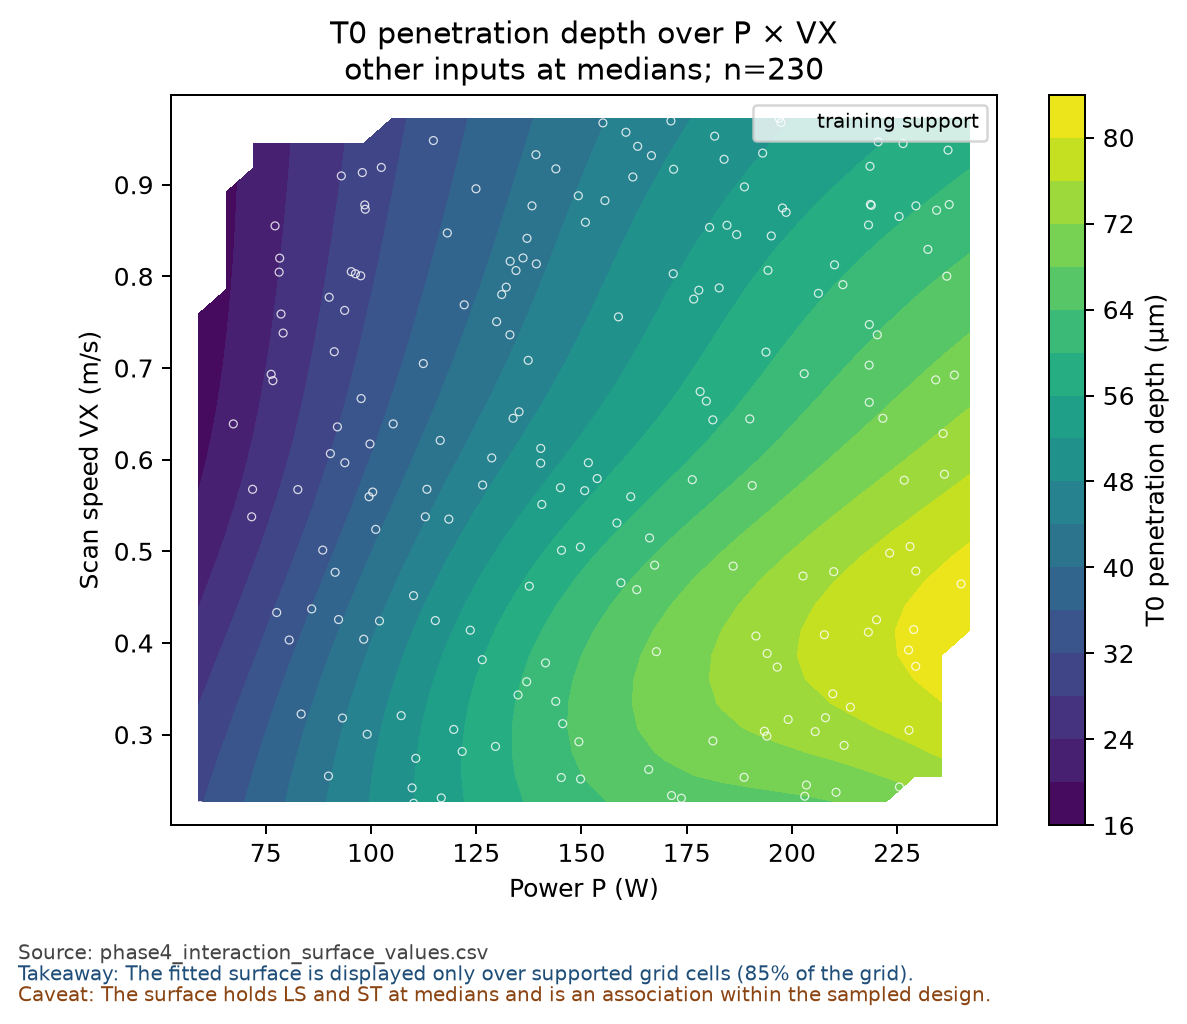

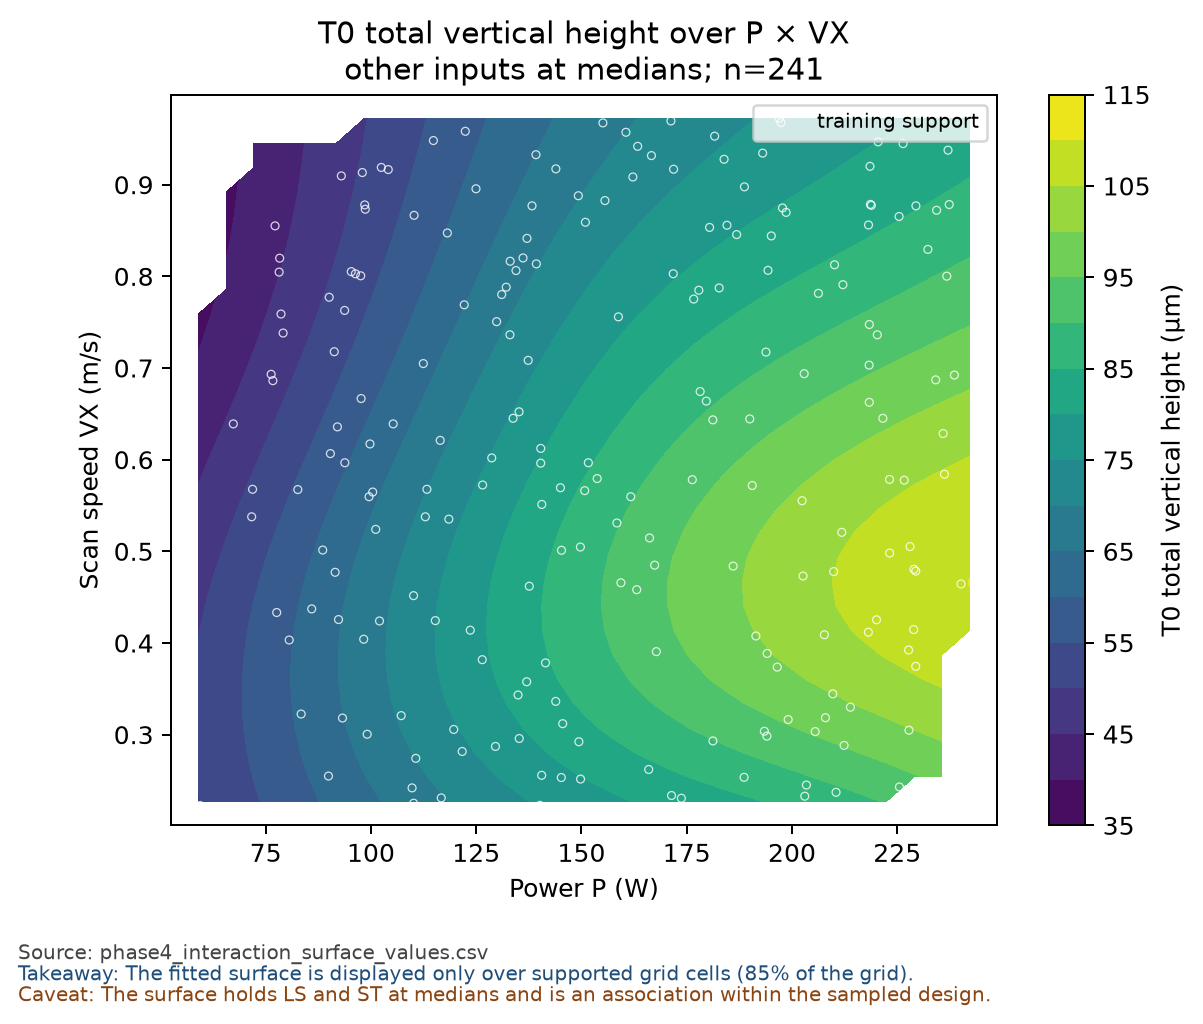

In [5]:
corr = pd.read_csv(OUT / "phase4_spearman_correlations.csv")
corr_ci = pd.read_csv(OUT / "phase4_spearman_bootstrap_intervals.csv")
ridge = pd.read_csv(OUT / "phase4_standardized_ridge_coefficients.csv")
support = pd.read_csv(OUT / "phase4_observed_support_summary.csv")

display(corr.merge(corr_ci, on=["response", "feature"]))
display(ridge)
display(support[[
    "response", "plot_type", "varying_features", "profile",
    "supported_fraction", "model_configuration", "training_sample_size"
]])
for figure_id, name in [
    (15, "spearman_input_output_overview"),
    (16, "standardized_ridge_coefficients"),
    (17, "width_vs_ls_controlled_curve"),
    (18, "kinetic_energy_vs_ls_power_profiles"),
    (19, "depth_P_VX_surface"),
    (20, "total_height_P_VX_surface"),
]:
    display(Image(filename=str(OUT / "figures" / f"{figure_id:02d}_{name}.png"), width=950))

Supervisor-focused readings:

- Width–LS: raw ρ=0.469; conditional standardized β=0.373.
- Kinetic-energy–LS: raw ρ=0.223; conditional β=0.017.
- Depth: ρ(P)=0.789, ρ(VX)=-0.438; conditional β(P)=0.819, β(VX)=-0.500.
- Total height: ρ(P)=0.801, ρ(VX)=-0.310; conditional β(P)=0.793, β(VX)=-0.377.

ST is reported in the same tables rather than interpreted selectively. Width reuses the Phase 3 Matérn 3/2 uncertainty GP; depth reuses it on the exact stable 230 population. These full-data fits support interpretation, not new model selection.

## E. Beam-normalized penetration diagnostics

**Beam-normalized penetration** divides depth by laser spot radius. Example: `50 µm / 50 µm = 1`, dimensionless. Absolute depth answers “how far below the surface?”; depth/LS answers “how large relative to the beam?”; depth/width answers “how deep and narrow?”

**Mathematical coupling through a denominator:** because LS appears in D/LS, LS can correlate negatively with D/LS partly by arithmetic even if absolute depth is unchanged. LS must therefore be interpreted primarily against absolute depth.

,simulation_id,LS,T0_penetration_depth_um,T0_depth_over_LS,G3,G3_over_LS,R0,R3,G3_over_LS_vs_R3_percentile_disagreement
0,sim_00001,45.000000,50.710190,1.126893,50.852430,1.130054,0.401777,0.417645,0.008333
1,sim_00002,88.288284,26.660185,0.301967,26.758460,0.303081,0.211691,0.233457,0.029167
2,sim_00003,76.636834,34.838855,0.454597,34.942480,0.455949,0.272347,0.275808,0.079167
3,sim_00004,87.530228,46.715575,0.533708,46.834655,0.535068,0.230016,0.239983,0.075000
4,sim_00005,45.000000,66.619015,1.480423,62.788960,1.395310,0.398655,0.382219,0.291667


,diagnostic_a,diagnostic_b,spearman_rho,sample_size,units,mathematical_coupling_warning_applies
0,T0_penetration_depth_um,T0_depth_over_LS,0.804065,241,um for absolute depth/G3; dimensionless for no...,True
1,T0_penetration_depth_um,G3,0.989073,240,um for absolute depth/G3; dimensionless for no...,False
2,T0_penetration_depth_um,G3_over_LS,0.801407,240,um for absolute depth/G3; dimensionless for no...,True
3,T0_penetration_depth_um,R0,0.638954,241,um for absolute depth/G3; dimensionless for no...,False
4,T0_penetration_depth_um,R3,0.607649,240,um for absolute depth/G3; dimensionless for no...,False
5,T0_depth_over_LS,G3,0.792664,240,um for absolute depth/G3; dimensionless for no...,True
6,T0_depth_over_LS,G3_over_LS,0.990631,240,um for absolute depth/G3; dimensionless for no...,True
7,T0_depth_over_LS,R0,0.831223,241,um for absolute depth/G3; dimensionless for no...,True
8,T0_depth_over_LS,R3,0.816712,240,um for absolute depth/G3; dimensionless for no...,True
9,G3,G3_over_LS,0.804694,240,um for absolute depth/G3; dimensionless for no...,True


,diagnostic,population,sample_size,minimum,q25,median,q75,maximum,mean,std,unstable_ids
0,T0_penetration_depth_um,all_241,241,15.102660,42.763700,54.753360,66.026160,122.200500,54.368745,17.228867,NaN
1,T0_penetration_depth_um,stable_230,230,18.778610,42.784705,54.722320,62.757203,94.365085,53.729585,15.501445,NaN
2,T0_penetration_depth_um,unstable_11,11,15.102660,28.731968,78.628320,86.352105,122.200500,67.732980,37.621831,"[""sim_00002"",""sim_00006"",""sim_00018"",""sim_0002..."
3,T0_depth_over_LS,all_241,241,0.175927,0.645913,0.868247,1.072733,2.715567,0.881188,0.351592,NaN
4,T0_depth_over_LS,stable_230,230,0.222860,0.658754,0.865190,1.054402,1.943630,0.859189,0.284982,NaN
5,T0_depth_over_LS,unstable_11,11,0.175927,0.340577,1.560230,1.806203,2.715567,1.341167,0.929037,"[""sim_00002"",""sim_00006"",""sim_00018"",""sim_0002..."
6,G3,all_241,240,18.560640,42.949759,54.907320,66.782036,234.534600,57.563652,24.292283,NaN
7,G3,stable_230,229,18.987800,42.955565,54.901590,66.687890,234.534600,56.196732,20.719801,NaN
8,G3,unstable_11,11,18.560640,28.863995,78.404255,136.626375,179.267800,86.020436,58.154295,"[""sim_00002"",""sim_00006"",""sim_00018"",""sim_0002..."
9,G3_over_LS,all_241,240,0.216209,0.670965,0.896040,1.103685,4.830689,0.937967,0.502901,NaN


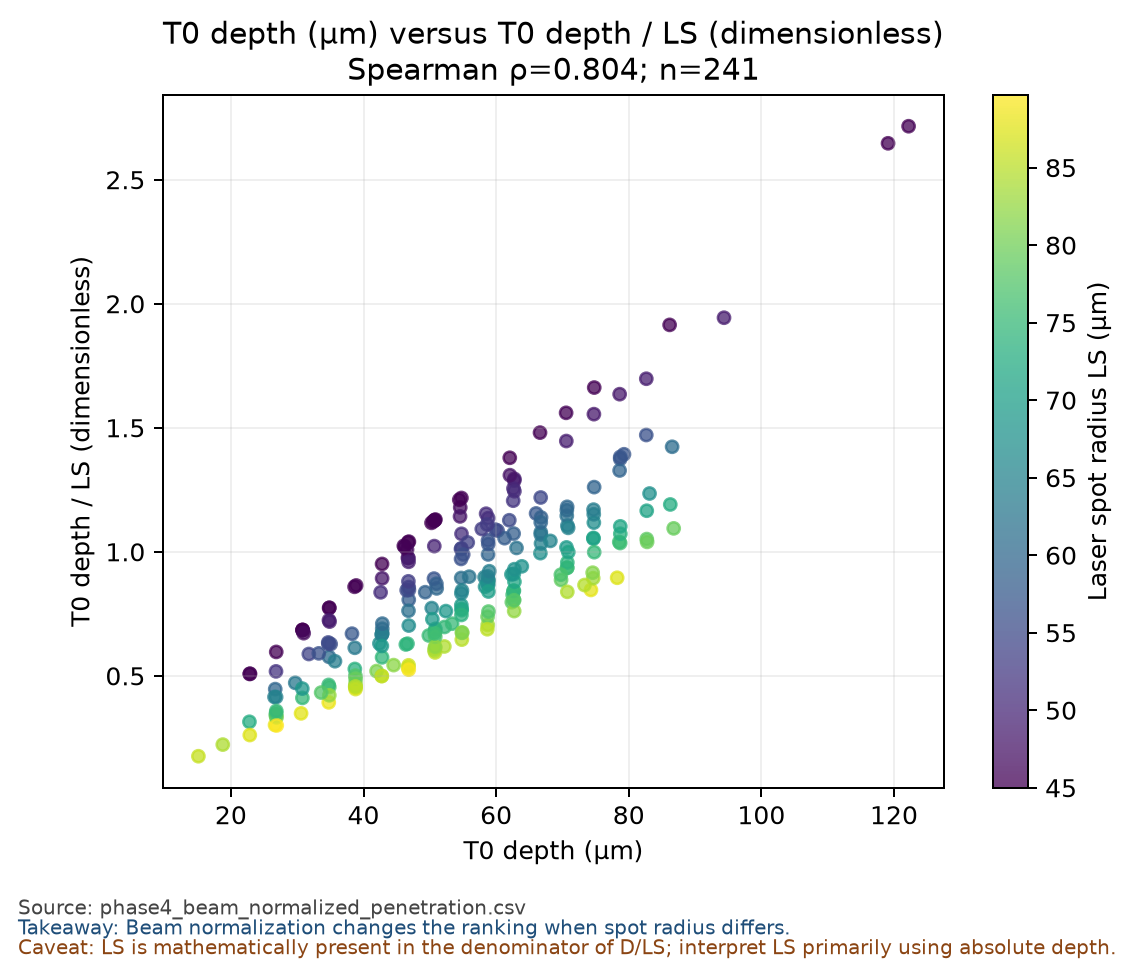

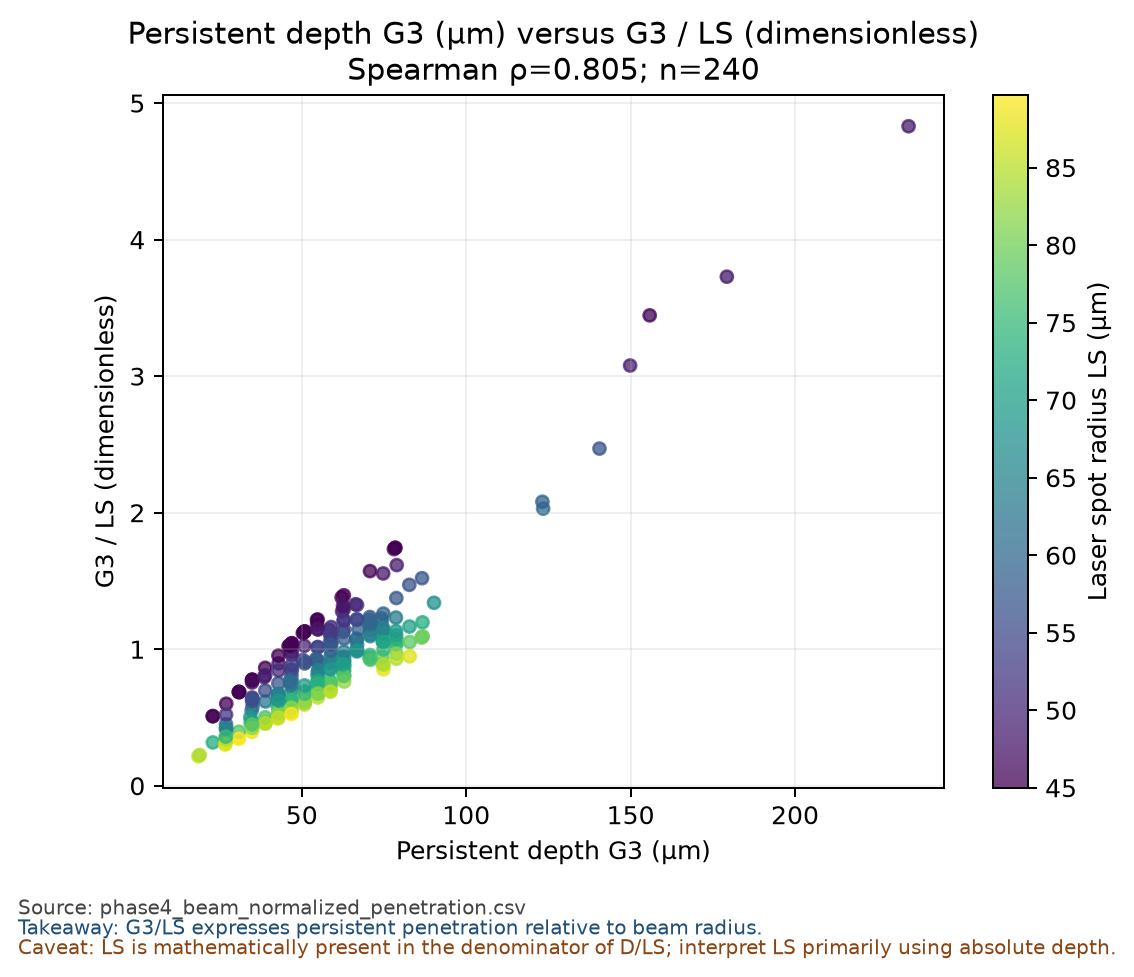

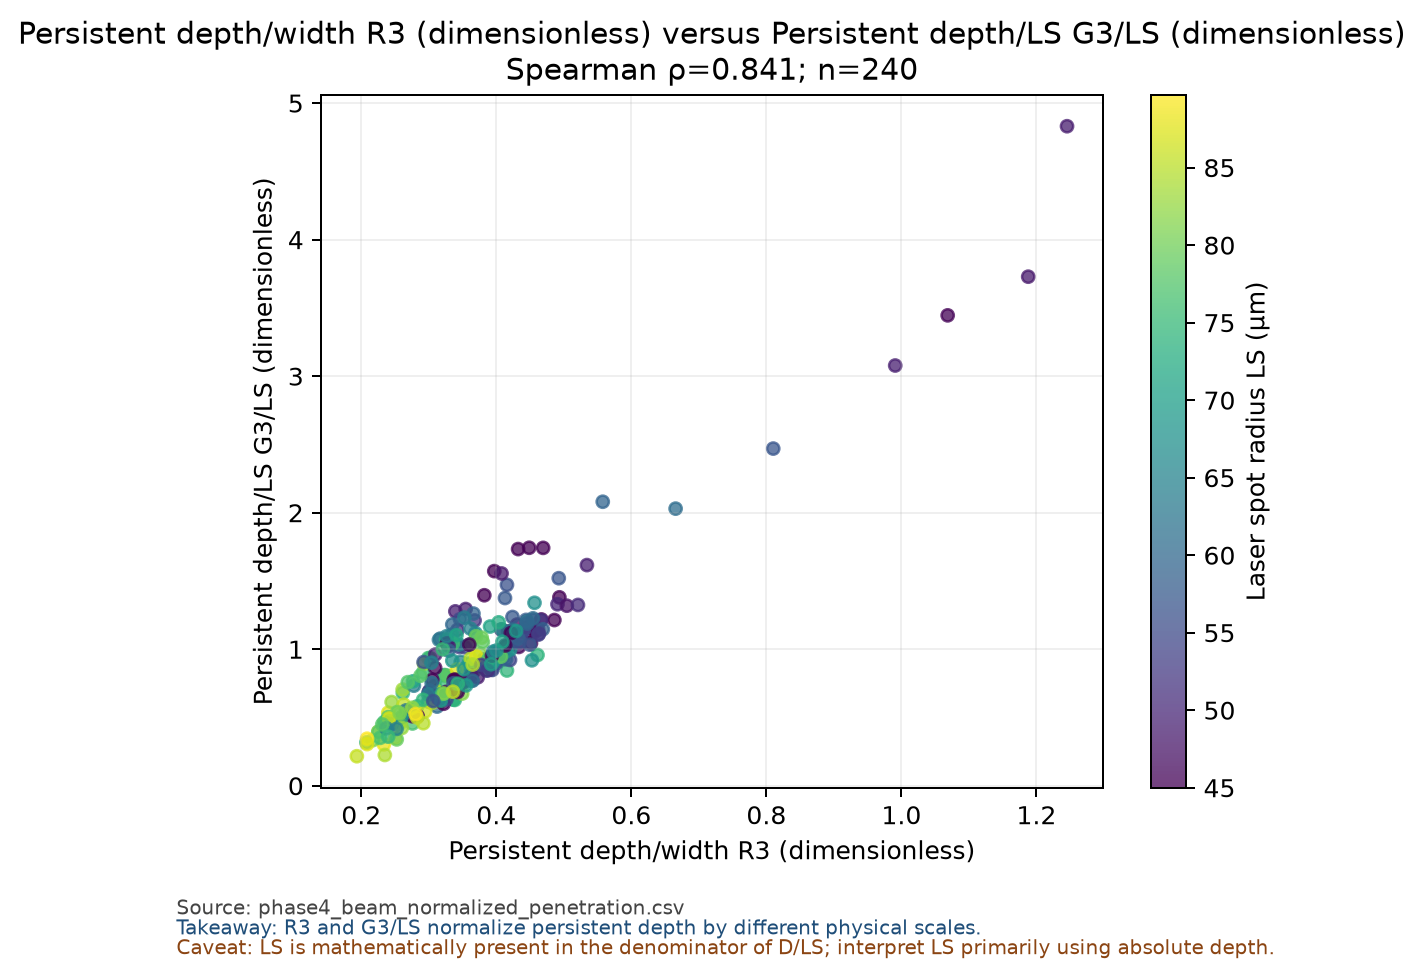

In [6]:
beam = pd.read_csv(OUT / "phase4_beam_normalized_penetration.csv")
beam_corr = pd.read_csv(OUT / "phase4_normalized_diagnostic_correlations.csv")
unstable = pd.read_csv(OUT / "phase4_normalized_diagnostic_unstable_sensitivity.csv")

display(beam[[
    "simulation_id", "LS", "T0_penetration_depth_um", "T0_depth_over_LS",
    "G3", "G3_over_LS", "R0", "R3",
    "G3_over_LS_vs_R3_percentile_disagreement"
]].head())
display(beam_corr)
display(unstable)
for figure_id, name in [
    (21, "t0_depth_vs_depth_over_ls"),
    (22, "g3_vs_g3_over_ls"),
    (23, "r3_vs_g3_over_ls"),
]:
    display(Image(filename=str(OUT / "figures" / f"{figure_id:02d}_{name}.png"), width=950))

`G3_over_LS` exactly equals persistent depth divided by LS because LS is constant within each simulation; no redundant time-series calculation is needed. Persistent G3/R3 quantities are available for 240 simulations; `sim_00101` lacks the Phase 3.5 adaptive interior. G3/LS and R3 can rank simulations differently because their denominators are beam radius and melt-pool width.

The unstable-11 table reports whether those simulations change distributions. High D/LS or R3 does not establish Keyhole. G3/LS is retained only for future analysis with more independent labels.

## F. Final conclusions and remaining caveats

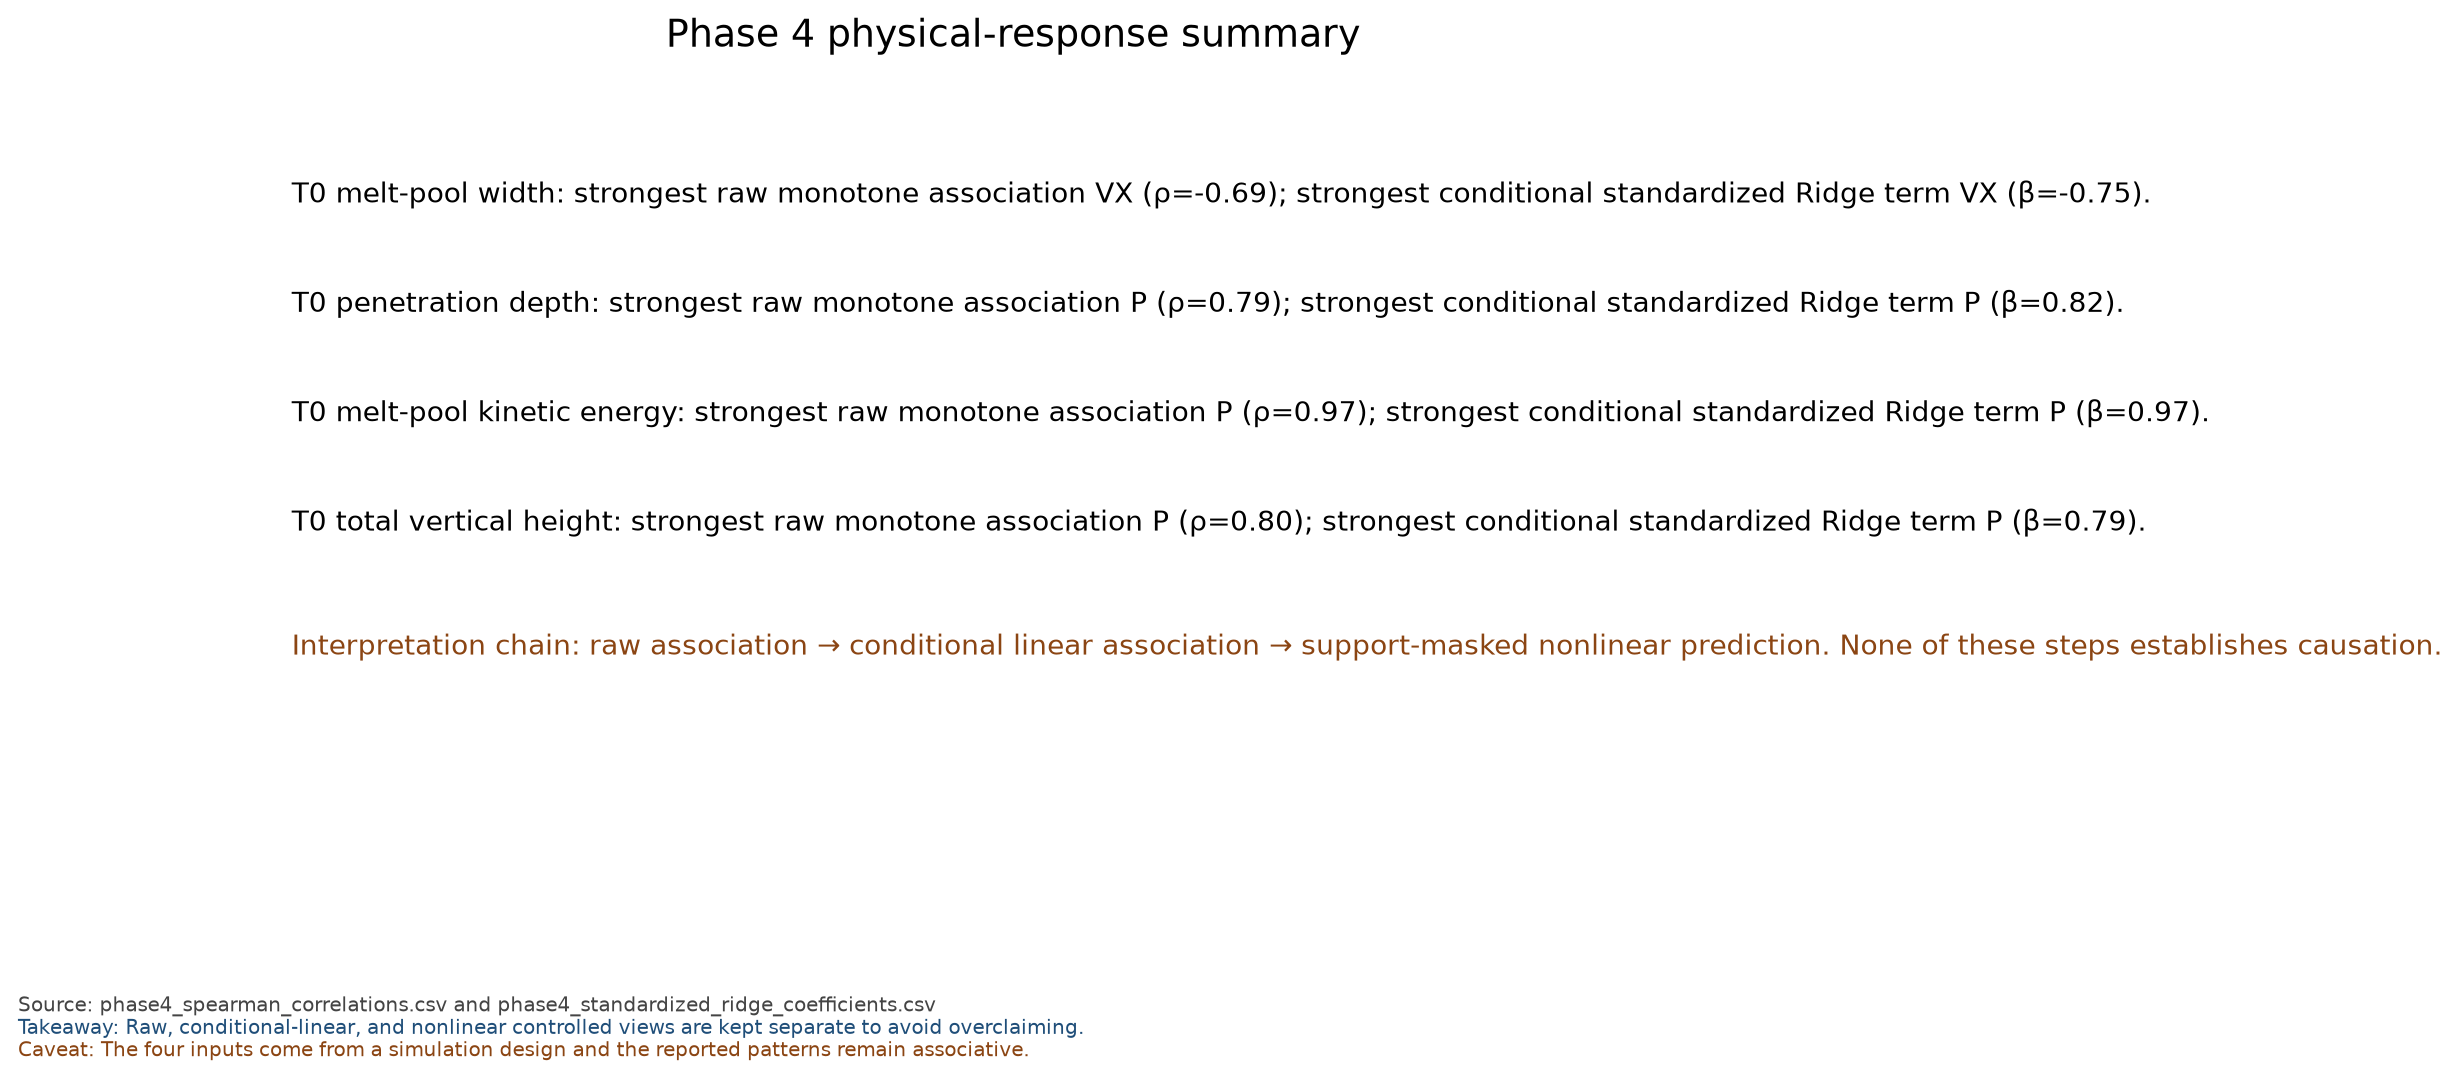

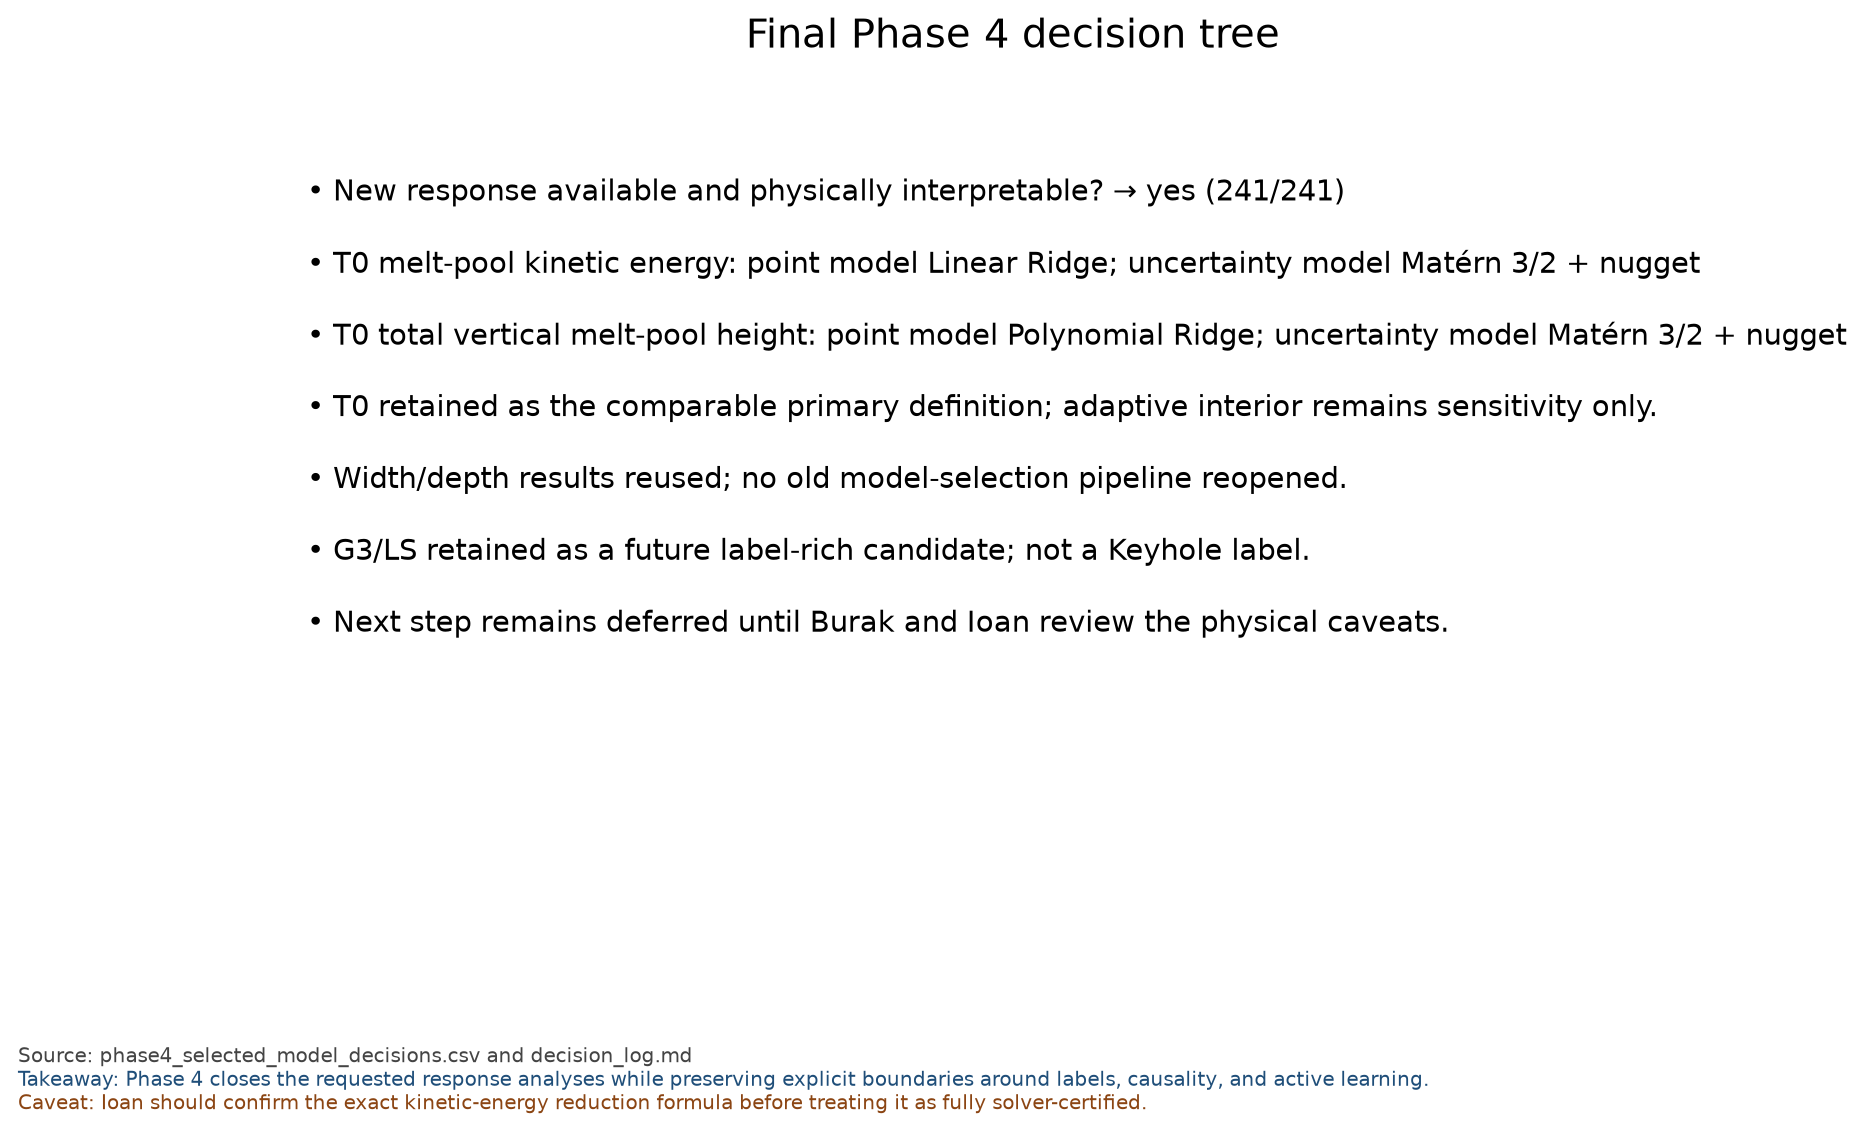

,figure_id,title,presentation_ready,file
0,1,Phase 4 analysis tree,False,outputs/week6_04_new_outputs_feature_effects/f...
1,2,Kinetic-energy monitor semantic audit,False,outputs/week6_04_new_outputs_feature_effects/f...
2,3,Example kinetic-energy time series,True,outputs/week6_04_new_outputs_feature_effects/f...
3,4,Example total-height time series beside penetr...,False,outputs/week6_04_new_outputs_feature_effects/f...
4,5,Population distribution of the two new targets,True,outputs/week6_04_new_outputs_feature_effects/f...
5,6,Primary-versus-adaptive target comparison,False,outputs/week6_04_new_outputs_feature_effects/f...
6,7,Representative kinetic-energy examples,False,outputs/week6_04_new_outputs_feature_effects/f...
7,8,Representative total-height examples,False,outputs/week6_04_new_outputs_feature_effects/f...
8,9,Baseline-versus-GP metric comparison for kinet...,True,outputs/week6_04_new_outputs_feature_effects/f...
9,10,Baseline-versus-GP metric comparison for total...,True,outputs/week6_04_new_outputs_feature_effects/f...


,category,status,count
0,automated validation,PASS,35
1,documentation,PASS,1
2,figure,PASS,25
3,models,PASS,4
4,normalized diagnostics,PASS,2
5,provenance,PASS,1
6,relationships,PASS,4
7,required output,PASS,28
8,safety,PASS,1
9,scope,PASS,1


In [7]:
checklist = pd.read_csv(OUT / "phase4_requirement_checklist.csv")
manifest = pd.read_csv(OUT / "figure_manifest.csv")
display(Image(filename=str(OUT / "figures" / "24_final_physical_response_summary.png"), width=950))
display(Image(filename=str(OUT / "figures" / "25_phase4_final_decision_tree.png"), width=950))
display(manifest[["figure_id", "title", "presentation_ready", "file"]])
display(checklist.groupby(["category", "status"]).size().rename("count").reset_index())

Phase 4 closes the new-response and focused-association questions while keeping the evidence boundaries explicit.

What remains uncertain: Ioan should confirm the kinetic reduction formula; controlled effects remain associations within observed support; R3 and G3/LS remain provisional regime descriptors. Active learning, classification, acquisition design, and level-set estimation are deferred until explicit review.

The figure manifest marks exactly ten presentation-ready figures. The full checklist maps every requirement to this notebook and its source output.